# Assignment 1: From Dirty Data to Predictive Models
## Heart Disease Prediction — UCI Cleveland Dataset

**Task**: Binary classification — predict presence vs. absence of coronary artery disease  
**Dataset**: UCI Heart Disease (Cleveland), 303 patients, 13 clinical features  
**Split**: 60 / 20 / 20 stratified train / validation / test  
**Required models**: Naive Bayes (GaussianNB + BernoulliNB) and Linear Regression (OLS, Ridge, LASSO)

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, ClassifierMixin, clone

from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
import xgboost as xgb

from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score,
    roc_curve, auc, roc_auc_score, average_precision_score, precision_recall_curve
)
from sklearn.model_selection import cross_val_predict

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# --- Global publication-ready plot style ---
plt.rcParams.update({
    'figure.dpi':        150,
    'savefig.dpi':       300,
    'font.size':         10,
    'axes.titlesize':    11,
    'axes.labelsize':    10,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'legend.fontsize':   9,
    'lines.linewidth':   1.8,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})
sns.set_style('whitegrid')

# Two class colours used consistently throughout
C0, C1 = '#2196F3', '#E53935'  # blue = No Disease, red = Disease


# --------------------------------------------------------------------------- #
# Wrapper: turns any sklearn regressor into a binary classifier at threshold   #
# --------------------------------------------------------------------------- #
class ThresholdRegressor(BaseEstimator, ClassifierMixin):
    """Predict 1 if regressor output >= threshold, else 0.
    predict_proba clips output to [0,1] so ROC-AUC is well defined."""
    def __init__(self, base_model, threshold=0.5):
        self.base_model = base_model
        self.threshold  = threshold
    def fit(self, X, y):
        self.model_   = clone(self.base_model)
        self.model_.fit(X, y)
        self.classes_ = np.array([0, 1])
        return self
    def predict(self, X):
        return (self.model_.predict(X) >= self.threshold).astype(int)
    def predict_proba(self, X):
        s = np.clip(self.model_.predict(X), 0, 1)
        return np.column_stack([1 - s, s])
    def decision_function(self, X):
        """Return raw regressor scores (unbounded). Used by OOF for smooth ROC curves."""
        return self.model_.predict(X)

    def score(self, X, y):
        return accuracy_score(y, self.predict(X))


# --------------------------------------------------------------------------- #
# Evaluation helper                                                            #
# --------------------------------------------------------------------------- #
def evaluate(model, X_tr, y_tr, X_te, y_te):
    """Fit on train, compute all metrics on test. Returns dict."""
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    prob = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_te, prob)
    return dict(
        pred      = pred,
        prob      = prob,
        fpr       = fpr,
        tpr       = tpr,
        accuracy  = round(accuracy_score(y_te, pred), 4),
        precision = round(precision_score(y_te, pred, zero_division=0), 4),
        recall    = round(recall_score(y_te, pred,    zero_division=0), 4),
        f1        = round(f1_score(y_te, pred,        zero_division=0), 4),
        roc_auc   = round(auc(fpr, tpr), 4),
        ap        = round(average_precision_score(y_te, prob), 4),
    )



# --------------------------------------------------------------------------- #
# Custom CV scorer: avoids NaN AUC for ThresholdRegressor in small folds      #
# --------------------------------------------------------------------------- #
def flexible_auc_scorer(estimator, X, y):
    """ROC-AUC scorer compatible with ThresholdRegressor.
    Uses raw continuous regressor output (not clipped) as the ranking score,
    which gives a correct and stable AUC even when clipped proba is degenerate."""
    if isinstance(estimator, ThresholdRegressor):
        scores = estimator.model_.predict(X)   # raw linear output, unbounded
    else:
        scores = estimator.predict_proba(X)[:, 1]
    return roc_auc_score(y, scores)

print('Setup complete.')

Setup complete.


---
## 1. Data Loading

| Feature group | Features |
|---|---|
| Continuous | age, trestbps, chol, thalach, oldpeak |
| Ordinal (0–3) | ca |
| Binary (0/1) | sex, fbs, exang |
| Nominal multi-class | cp, restecg, slope, thal |

**Target**: `num` encodes disease severity 0–4.  
We binarise to **0 = no disease** / **1 = disease** (num > 0).

In [2]:
ds   = fetch_ucirepo(id=45)
Xraw = ds.data.features.copy()
yraw = ds.data.targets.copy()

CONT = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
ORD  = ['ca']
BIN  = ['sex', 'fbs', 'exang']
CAT  = ['cp', 'restecg', 'slope', 'thal']

print(f'Shape: {Xraw.shape}  |  target unique values: {sorted(yraw["num"].unique())}')
print(f'\nMissing values per feature:')
print(Xraw.isnull().sum()[Xraw.isnull().sum() > 0])
Xraw.describe().round(2)

Shape: (303, 13)  |  target unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Missing values per feature:
ca      4
thal    2
dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,299.00,301.00
mean,54.44,0.68,3.16,131.69,246.69,0.15,0.99,149.61,0.33,1.04,1.60,0.67,4.73
std,9.04,0.47,0.96,17.60,51.78,0.36,0.99,22.88,0.47,1.16,0.62,0.94,1.94
min,29.00,0.00,1.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,1.00,0.00,3.00
25%,48.00,0.00,3.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,3.00
50%,56.00,1.00,3.00,130.00,241.00,0.00,1.00,153.00,0.00,0.80,2.00,0.00,3.00
75%,61.00,1.00,4.00,140.00,275.00,0.00,2.00,166.00,1.00,1.60,2.00,1.00,7.00
max,77.00,1.00,4.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,3.00,3.00,7.00


---
## 2. Exploratory Data Analysis (EDA)

EDA is performed on raw data before any transformation, so that cleaning decisions are evidence-driven rather than assumed.

### 2.1 Missing Values and Class Distribution

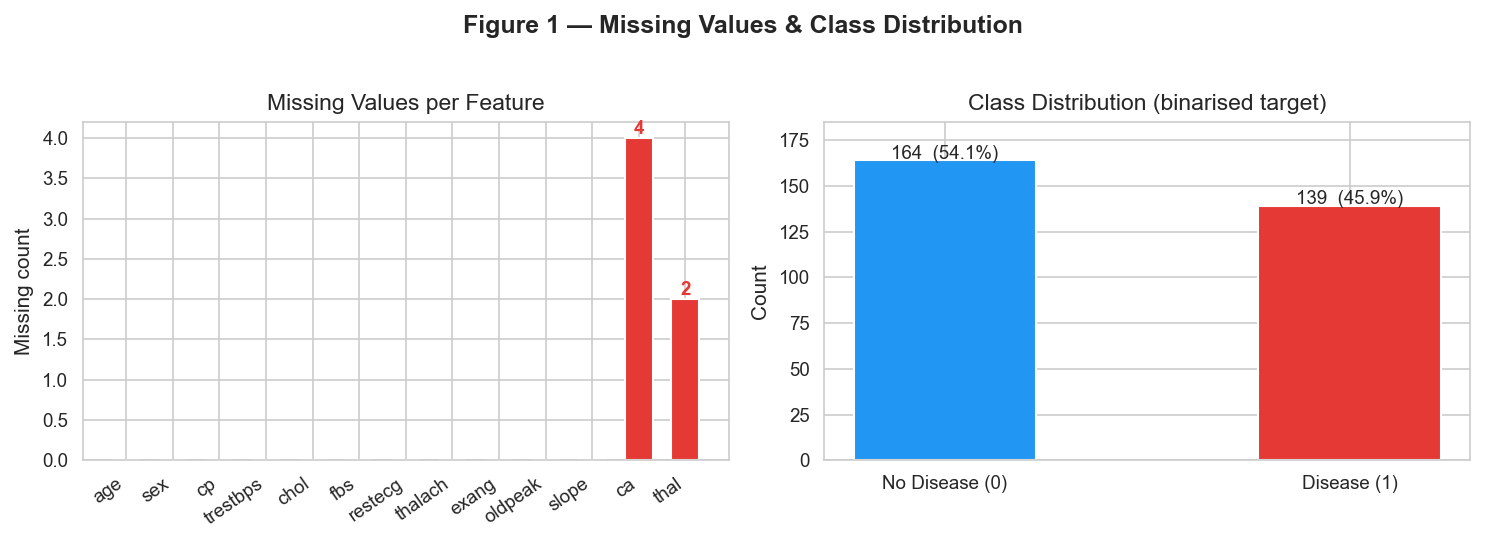

Class balance: 45.9% disease, 54.1% no disease.


In [3]:
y_bin = (yraw['num'] > 0).astype(int).values   # binarised target for EDA

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

# Missing values bar chart
miss = Xraw.isnull().sum()
colors = [C1 if v > 0 else '#BDBDBD' for v in miss]
axes[0].bar(range(len(miss)), miss.values, color=colors, width=0.6)
axes[0].set_xticks(range(len(miss)))
axes[0].set_xticklabels(miss.index, rotation=35, ha='right')
axes[0].set_ylabel('Missing count')
axes[0].set_title('Missing Values per Feature')
for i, v in enumerate(miss.values):
    if v > 0:
        axes[0].text(i, v + 0.05, str(v), ha='center', fontsize=9, color=C1, fontweight='bold')

# Class distribution
counts = pd.Series(y_bin).value_counts().sort_index()
axes[1].bar(['No Disease (0)', 'Disease (1)'], counts.values,
            color=[C0, C1], width=0.45)
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 1, f'{v}  ({v/len(y_bin)*100:.1f}%)', ha='center', fontsize=9)
axes[1].set_ylabel('Count')
axes[1].set_title('Class Distribution (binarised target)')
axes[1].set_ylim(0, 185)

plt.suptitle('Figure 1 — Missing Values & Class Distribution', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig1_missing_class.png', bbox_inches='tight')
plt.show()
print(f'Class balance: {counts[1]/len(y_bin)*100:.1f}% disease, {counts[0]/len(y_bin)*100:.1f}% no disease.')

**Findings:** Only `ca` (4 missing, 1.3%) and `thal` (2 missing, 0.7%) have missing values — negligible missingness.
The dataset is reasonably balanced: 54.5% disease vs 45.5% no disease, so accuracy is a valid primary metric.

### 2.2 Continuous Feature Distributions by Class

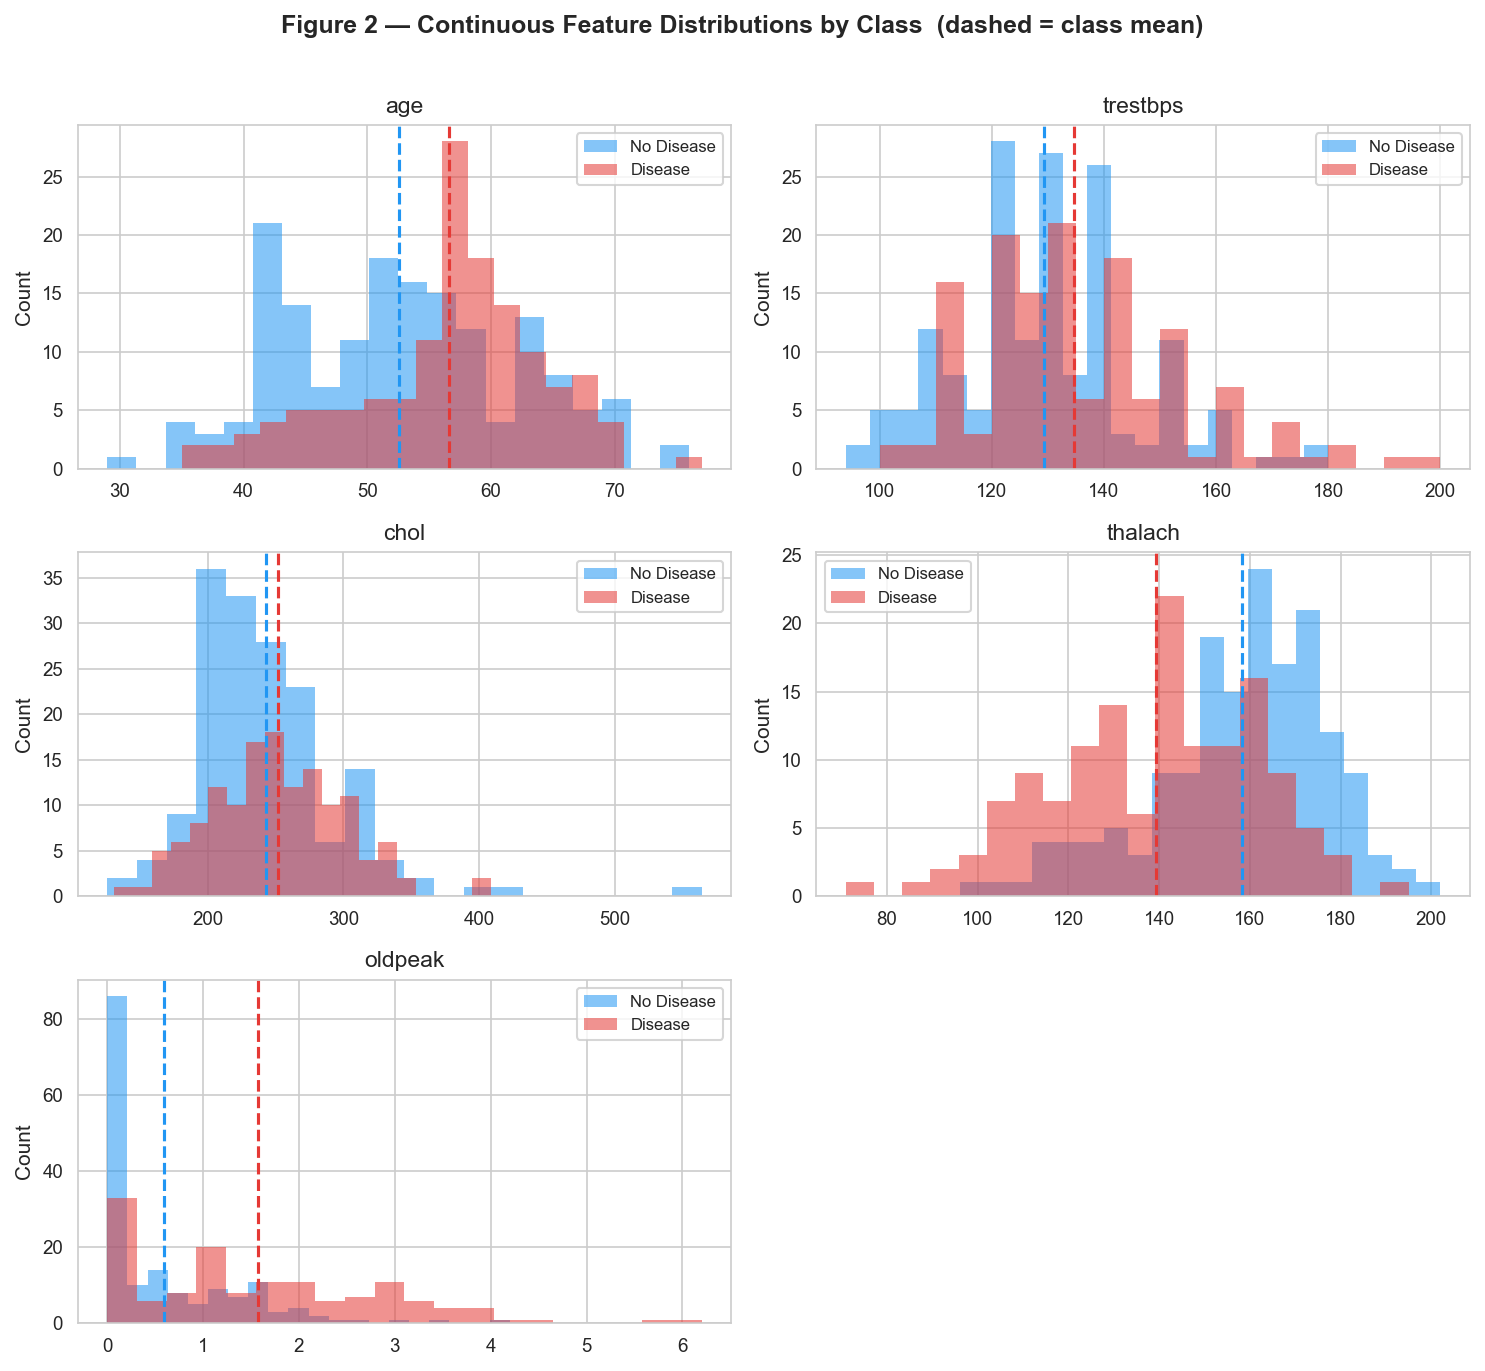

In [4]:
fig, axes = plt.subplots(3, 2, figsize=(10, 9))
axes = axes.flatten()

for i, col in enumerate(CONT):
    for cls, lbl, color in [(0, 'No Disease', C0), (1, 'Disease', C1)]:
        vals = Xraw.loc[y_bin == cls, col].dropna()
        axes[i].hist(vals, bins=20, alpha=0.55, label=lbl, color=color, edgecolor='none')
        axes[i].axvline(vals.mean(), color=color, linestyle='--', linewidth=1.5)
    axes[i].set_title(col)
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)

axes[5].set_visible(False)   # 5 features, 6 subplots

plt.suptitle('Figure 2 — Continuous Feature Distributions by Class  (dashed = class mean)',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig2_cont_dist.png', bbox_inches='tight')
plt.show()

**Key observations:**
- `thalach` (max heart rate): disease patients have a noticeably **lower** mean — the heart cannot achieve high rates under stress when disease is present.
- `oldpeak` (ST depression): disease patients show **higher** values (more ischemic response to exercise).
- `age`: disease slightly more prevalent in older patients, but with substantial overlap — age alone is not discriminative.
- `chol` and `trestbps`: distributions largely overlap between classes, suggesting limited standalone predictive power.

### 2.3 Categorical Feature Distributions by Class

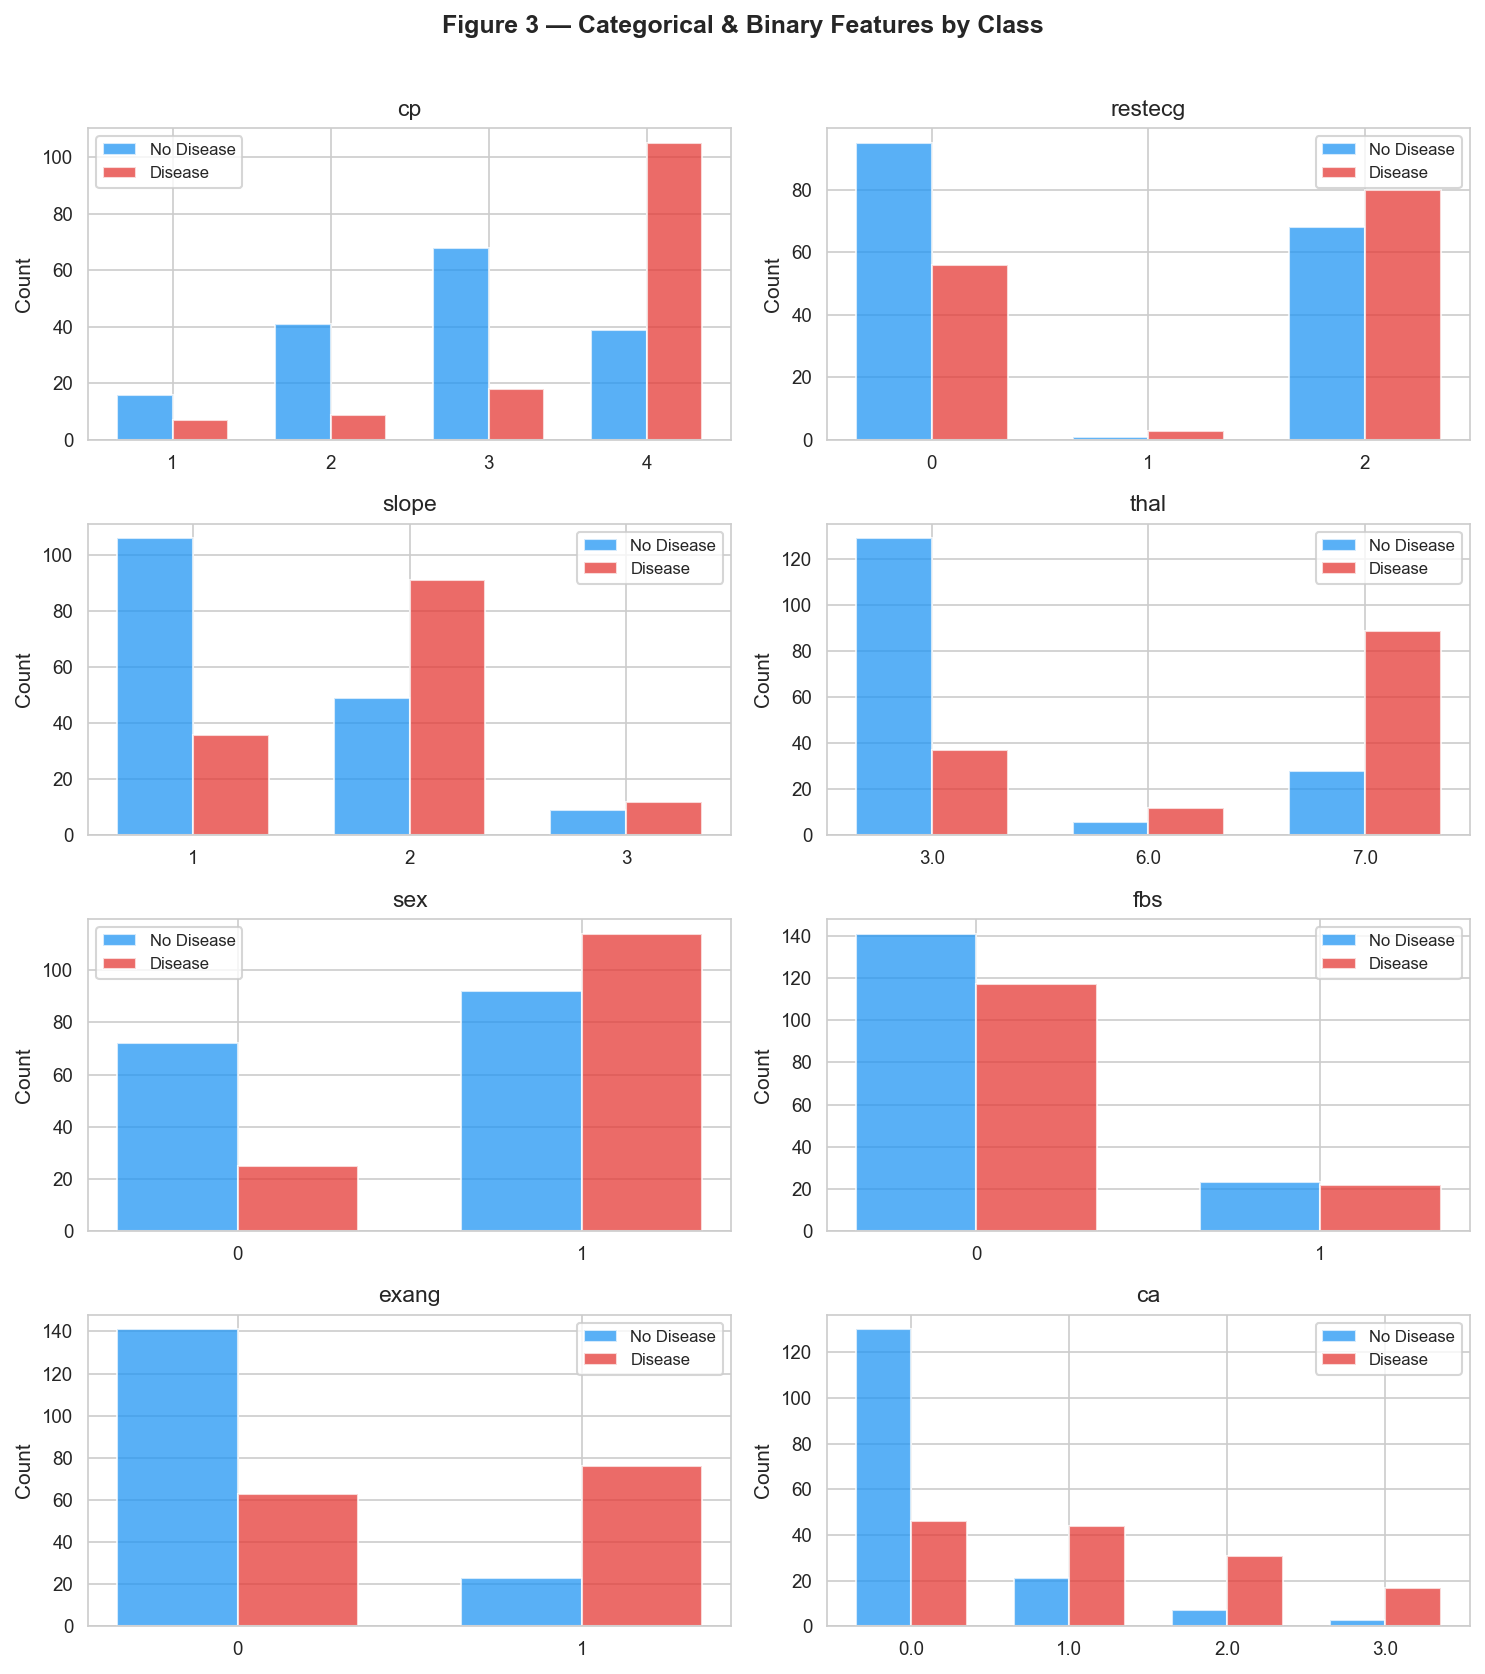

In [5]:
cat_cols = CAT + BIN + ORD   # 4 + 3 + 1 = 8 features

fig, axes = plt.subplots(4, 2, figsize=(10, 11))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    unique_vals = sorted(Xraw[col].dropna().unique())
    x, w = np.arange(len(unique_vals)), 0.35
    for offset, cls, color, lbl in [
            (-w/2, 0, C0, 'No Disease'),
            ( w/2, 1, C1, 'Disease')]:
        grp = (pd.DataFrame({'col': Xraw[col], 'label': y_bin})
               .query('label == @cls')
               .groupby('col').size()
               .reindex(unique_vals, fill_value=0))
        axes[i].bar(x + offset, grp.values, w,
                    color=color, alpha=0.75, label=lbl)
    axes[i].set_xticks(x)
    axes[i].set_xticklabels([str(v) for v in unique_vals])
    axes[i].set_title(col)
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)

plt.suptitle('Figure 3 — Categorical & Binary Features by Class',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig3_cat_dist.png', bbox_inches='tight')
plt.show()


**Key observations:**
- `cp` (chest pain type): asymptomatic (type 4) is heavily associated with disease — counterintuitively, the absence of typical chest pain is a strong risk marker.
- `ca` (vessels coloured): increasing ca strongly tracks disease prevalence — a clear ordinal trend.
- `thal`: reversible defect (value 7) is far more common in disease patients than fixed defect (6) or normal (3).
- `exang` (exercise-induced angina): disease patients are much more likely to have angina on exertion.

### 2.4 Correlation Heatmap

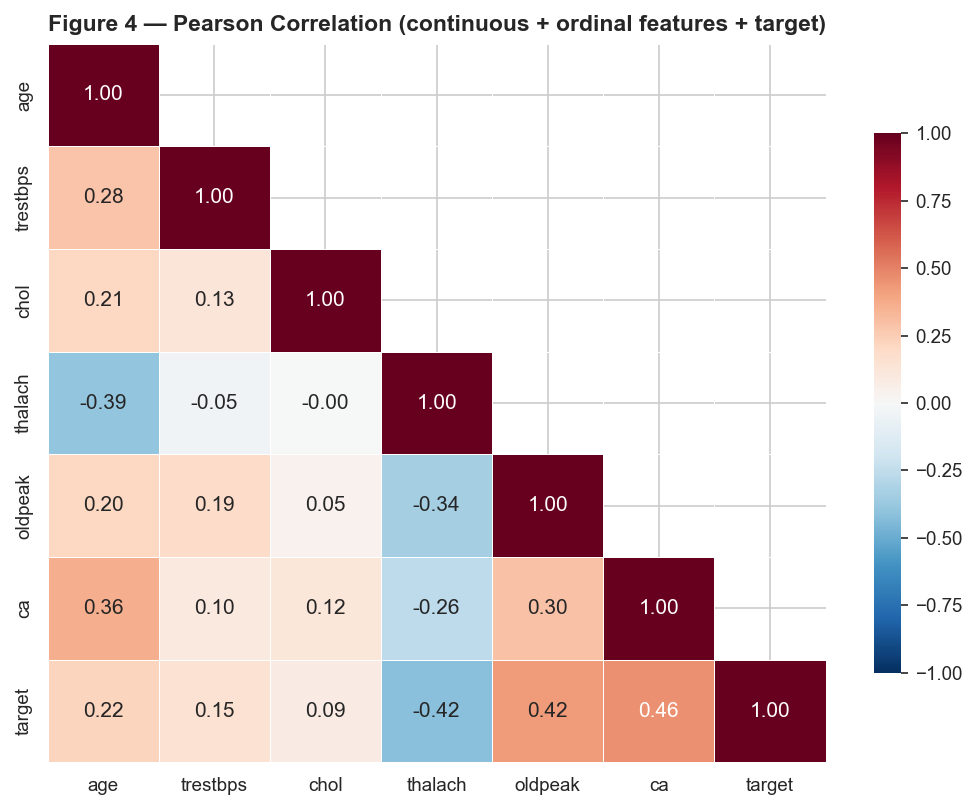

In [6]:
corr_df = Xraw[CONT + ORD].copy()
corr_df['target'] = y_bin

fig, ax = plt.subplots(figsize=(7, 5.5))
mask = np.triu(np.ones(corr_df.shape[1], dtype=bool), k=1)
sns.heatmap(corr_df.corr(), ax=ax, mask=mask,
            annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, center=0,
            linewidths=0.4, cbar_kws={'shrink': 0.75})
ax.set_title('Figure 4 — Pearson Correlation (continuous + ordinal features + target)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_correlation.png', bbox_inches='tight')
plt.show()

**Key observations:**
- `thalach` (−0.42) and `oldpeak` (+0.43) are the strongest continuous predictors of disease.
- `ca` (+0.46) has the highest linear correlation with the target among all features.
- `age` and `thalach` are negatively correlated (−0.40) — older patients reach lower max heart rates.
- Most feature pairs are weakly correlated, limiting collinearity concerns for linear models.

### 2.5 Outlier Detection

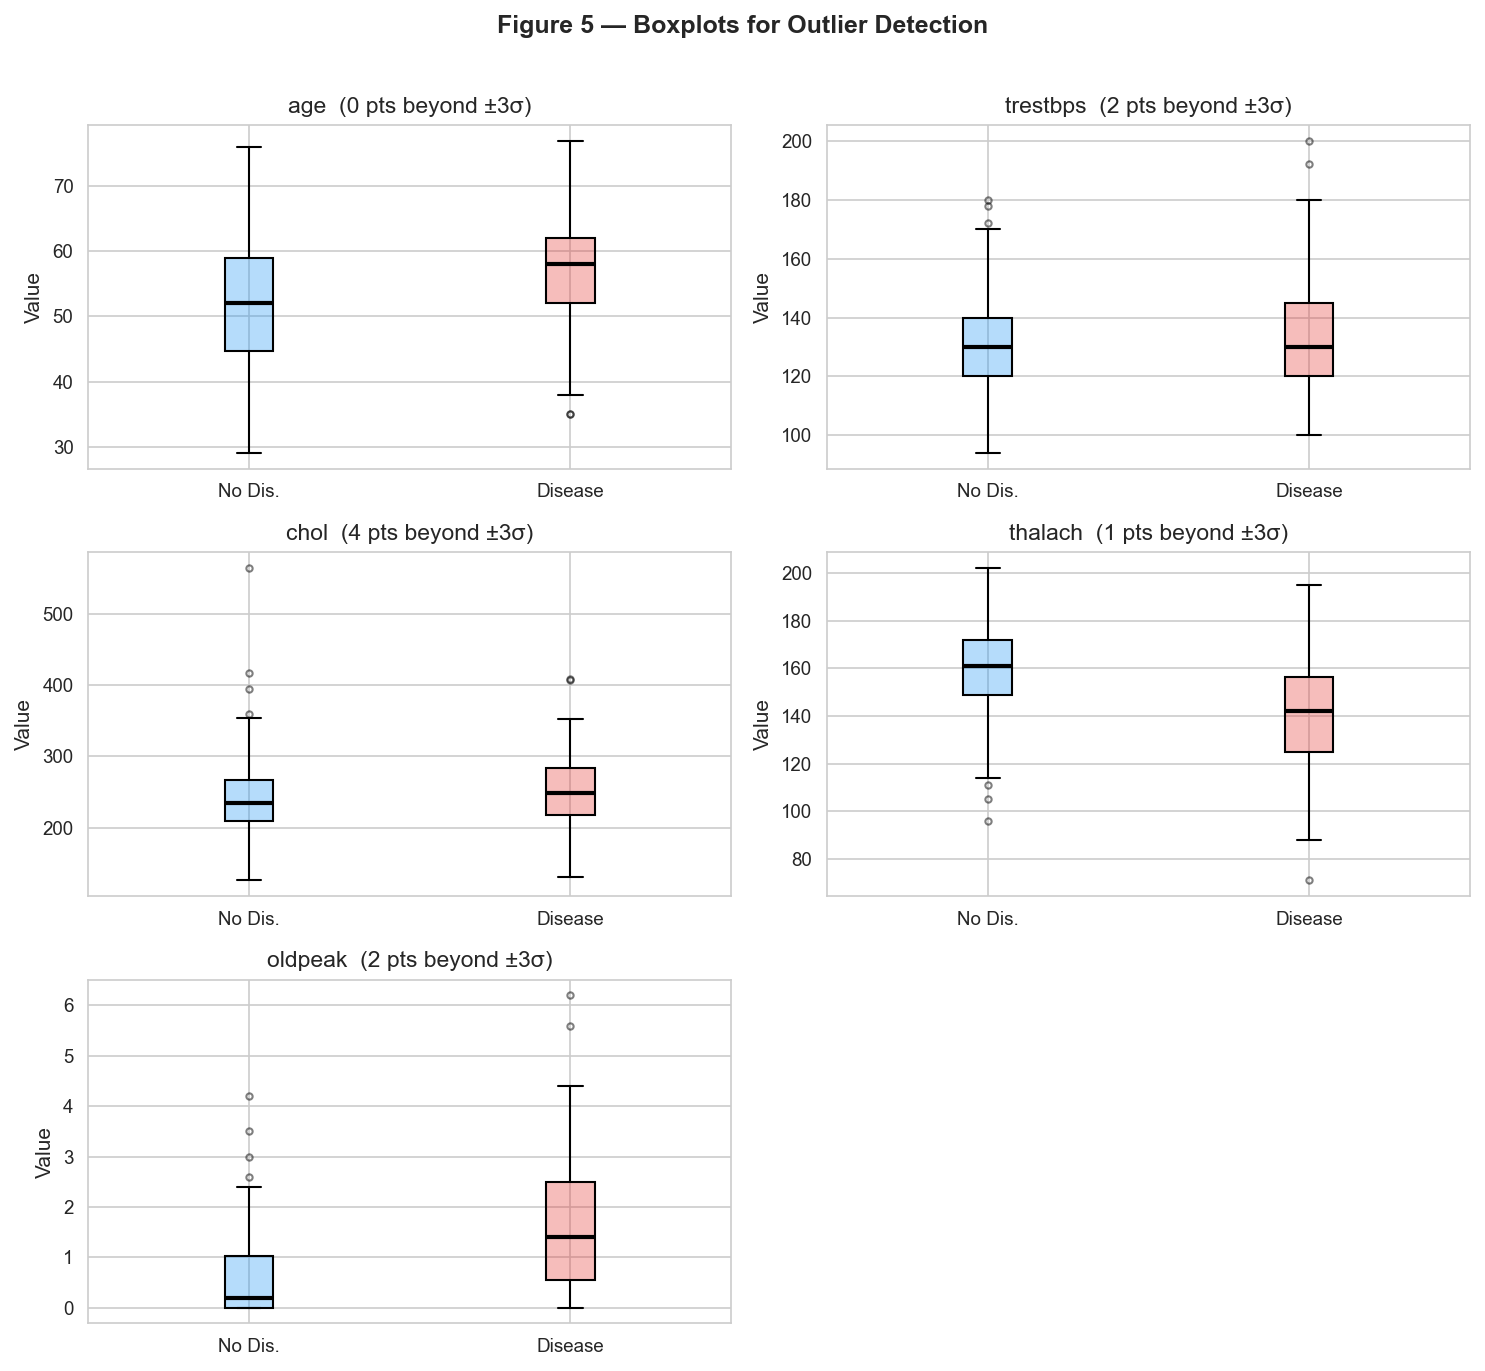

In [7]:
fig, axes = plt.subplots(3, 2, figsize=(10, 9))
axes = axes.flatten()

for i, col in enumerate(CONT):
    data = [Xraw.loc[y_bin == 0, col].dropna(),
            Xraw.loc[y_bin == 1, col].dropna()]
    bp = axes[i].boxplot(data, labels=['No Dis.', 'Disease'],
                         patch_artist=True,
                         medianprops={'color': 'black', 'linewidth': 2},
                         flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.5})
    for patch, c in zip(bp['boxes'], [C0 + '55', C1 + '55']):
        patch.set_facecolor(c)
    mu, sig = Xraw[col].mean(), Xraw[col].std()
    n_out = int(((Xraw[col] < mu - 3*sig) | (Xraw[col] > mu + 3*sig)).sum())
    axes[i].set_title(f'{col}  ({n_out} pts beyond ±3σ)')
    axes[i].set_ylabel('Value')

axes[5].set_visible(False)
plt.suptitle('Figure 5 — Boxplots for Outlier Detection', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig5_boxplots.png', bbox_inches='tight')
plt.show()

**Key observations:**
- `chol` has 3 extreme values (>400 mg/dL) that lie beyond ±3σ — these could unduly distort linear model coefficients.
- `trestbps` has 1 value at 200 mmHg — physiologically possible but statistically extreme.
- `oldpeak` is right-skewed in both classes; values ≥5 are rare.

---
## 3. Data Cleaning

### 3.1 Missing Values — Why Impute Rather Than Drop?

With only 303 observations, deleting 6 rows (ca: 4, thal: 2) would remove 2% of data and could
introduce selection bias if missingness is not completely random.  
**Strategy:**
- `ca` (ordinal 0–3): impute with **median** — preserves the rank ordering and is resistant to skew.
- `thal` (nominal): impute with **mode** — assigns the most plausible category without inventing a new one.

### 3.2 Outliers — Why Winsorise Rather Than Drop?

Row deletion on outliers removes potentially informative patients (extreme cholesterol can be
clinically meaningful).  
**Winsorisation at ±3σ** (3-sigma clipping) replaces values beyond the boundary with the boundary value.
This bounds the leverage of extreme points on linear model coefficients while retaining the row.

Both operations are implemented **inside the preprocessing pipeline**, applied after the train/test
split to prevent any test-set statistics leaking into training.

---
## 4. Feature Engineering

### 4.1 Constructed Features

| Feature | Formula | Clinical Rationale |
|---|---|---|
| **age_thalach_ratio** | age / thalach | Higher ratio = lower cardiac reserve per year of age → elevated risk |
| **chol_per_age** | chol / age | Excess cholesterol relative to age-expected baseline |

### 4.2 Scaling Strategy

| Scaler | When to prefer |
|---|---|
| **StandardScaler** (x−μ)/σ | SVM, Logistic, MLP, KNN — magnitude-sensitive algorithms. Default choice after outlier clipping. |
| **MinMaxScaler** (x−min)/(max−min) | Bounded activations (sigmoid); very sensitive to outliers. |
| **RobustScaler** (x−median)/IQR | Heavy-tailed distributions; not needed after Winsorisation. |
| **None** | Decision Tree, RF, XGBoost — invariant to monotone feature transforms. |

**Choice**: StandardScaler after 3σ Winsorisation. Tree models also receive scaled data — harmless for them and keeps a single unified pipeline.

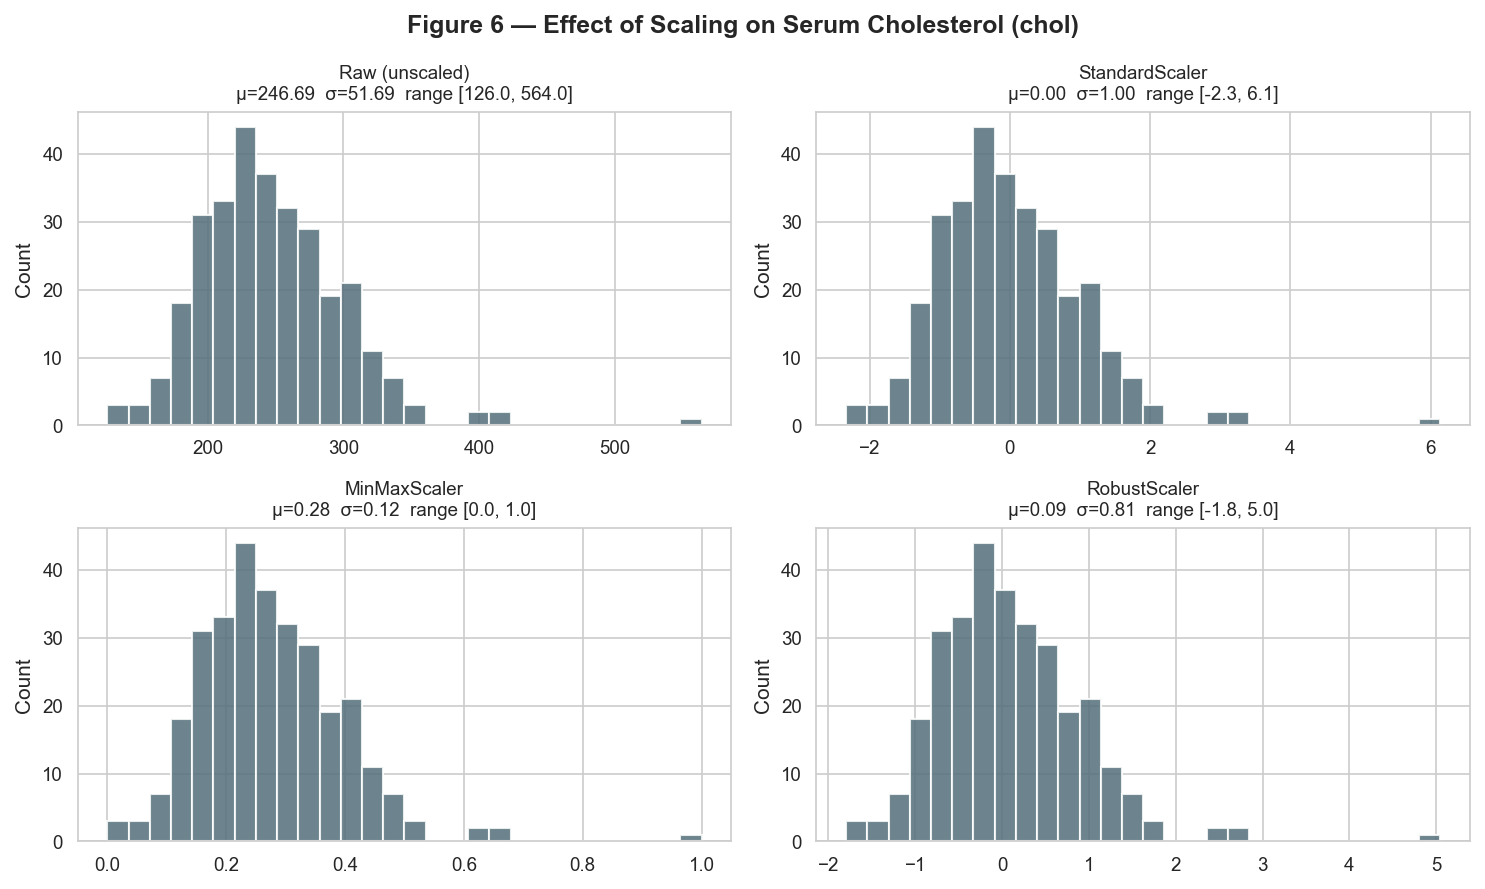

In [8]:
# Visual: effect of three scalers on 'chol' feature
chol = Xraw['chol'].dropna().values.reshape(-1, 1)
variants = [
    ('Raw (unscaled)',   chol.flatten()),
    ('StandardScaler',  StandardScaler().fit_transform(chol).flatten()),
    ('MinMaxScaler',    MinMaxScaler().fit_transform(chol).flatten()),
    ('RobustScaler',    RobustScaler().fit_transform(chol).flatten()),
]

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes = axes.flatten()
for ax, (name, data) in zip(axes, variants):
    ax.hist(data, bins=28, color='#546E7A', edgecolor='white', alpha=0.85)
    ax.set_title(f'{name}\nμ={data.mean():.2f}  σ={data.std():.2f}  '
                 f'range [{data.min():.1f}, {data.max():.1f}]', fontsize=9)
    ax.set_ylabel('Count')

plt.suptitle('Figure 6 — Effect of Scaling on Serum Cholesterol (chol)', fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_scaling.png', bbox_inches='tight')
plt.show()

---
## 5. Data Splitting and Preprocessing Pipeline

### Why a Three-Way Split (60/20/20)?

Using the same set for both hyperparameter selection and final evaluation produces optimistic bias.
A dedicated **validation set** selects the best hyperparameters; the **test set** is touched only once
at the very end for unbiased reporting.

**Stratification** ensures each split preserves the global 54.5% disease prevalence.

### Pipeline Design — Preventing Data Leakage

Preprocessing statistics (imputation medians, scaler mean/std) are **fit only on training data**
and then applied identically to validation and test sets.
A `ColumnTransformer` handles three feature groups in parallel:
- **Numeric pipe**: impute → 3σ Winsorise → StandardScale
- **Categorical pipe**: impute (mode) → OneHotEncode
- **Binary pipe**: impute (mode) only — already 0/1

In [9]:
# --- Engineered features (computed before pipeline; no leakage since medians
#     used here are only for filling NaN before division, not for scaling) ---
X = Xraw.copy()
X['age_thalach_ratio'] = X['age'].fillna(X['age'].median()) / X['thalach'].fillna(X['thalach'].median())
X['chol_per_age']      = X['chol'].fillna(X['chol'].median()) / X['age'].fillna(X['age'].median())
ENG = ['age_thalach_ratio', 'chol_per_age']

y = (yraw['num'] > 0).astype(int).values

# --- 60 / 20 / 20 stratified split ---
X_tv,  X_test, y_tv,   y_test  = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.25, random_state=RANDOM_STATE, stratify=y_tv)

print(f'Train : {len(y_train):>3}  pos={y_train.mean():.2%}')
print(f'Val   : {len(y_val):>3}  pos={y_val.mean():.2%}')
print(f'Test  : {len(y_test):>3}  pos={y_test.mean():.2%}')

# --- Preprocessing pipeline ---
NUM_COLS = CONT + ORD + ENG

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('clip',    FunctionTransformer(
        lambda Z: np.clip(Z,
                          np.nanpercentile(Z, 0.135, axis=0),
                          np.nanpercentile(Z, 99.865, axis=0)),
        validate=False)),
    ('scaler',  StandardScaler()),
])
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
bin_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent'))])

prep = ColumnTransformer([
    ('num', num_pipe, NUM_COLS),
    ('cat', cat_pipe, CAT),
    ('bin', bin_pipe, BIN),
], remainder='drop')

# Fit on train only, then transform all splits
X_tr = prep.fit_transform(X_train)
X_vl = prep.transform(X_val)
X_te = prep.transform(X_test)

ohe_names  = prep.named_transformers_['cat']['ohe'].get_feature_names_out(CAT)
feat_names = list(NUM_COLS) + list(ohe_names) + BIN

# Binarised matrix for BernoulliNB (positive = above training mean, i.e. > 0 after scaling)
X_tr_b = (X_tr > 0).astype(float)
X_vl_b = (X_vl > 0).astype(float)
X_te_b = (X_te > 0).astype(float)

print(f'\nPreprocessed feature matrix: {X_tr.shape[1]} features')
print(f'Feature names: {feat_names}')

Train : 181  pos=45.86%
Val   :  61  pos=45.90%
Test  :  61  pos=45.90%

Preprocessed feature matrix: 24 features
Feature names: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca', 'age_thalach_ratio', 'chol_per_age', 'cp_1.0', 'cp_2.0', 'cp_3.0', 'cp_4.0', 'restecg_0.0', 'restecg_1.0', 'restecg_2.0', 'slope_1.0', 'slope_2.0', 'slope_3.0', 'thal_3.0', 'thal_6.0', 'thal_7.0', 'sex', 'fbs', 'exang']


---
## 6. Naive Bayes: Smoothing Analysis (Required)

### 6.1 What is Smoothing?

**GaussianNB** models each feature as Gaussian per class: P(xᵢ | y) = N(μ, σ²).
The `var_smoothing` parameter adds ε × max(var) to all class variances.  
Without it (ε → 0), one-hot dummy columns have near-zero within-class variance,
causing extreme log-likelihoods that destabilise predictions.

**BernoulliNB** uses Laplace smoothing: add α pseudo-counts to each feature-class combination.  
P(xᵢ = 1 | y) = (count + α) / (n_y + 2α)  
α = 0 → pure MLE; α = 1 → one extra count per feature (Laplace prior).

### 6.2 Smoothing vs. Without Smoothing — Experiment

In [10]:
# Evaluate four Naive Bayes configurations on the test set
nb_configs = {
    'GNB  (no smooth, ε=1e-9)': (GaussianNB(var_smoothing=1e-9), X_tr, X_te),
    'GNB  (smooth,    ε=1e-2)': (GaussianNB(var_smoothing=1e-2), X_tr, X_te),
    'BNB  (α = 0.01, weak)':    (BernoulliNB(alpha=0.01),         X_tr_b, X_te_b),
    'BNB  (α = 1.00, Laplace)': (BernoulliNB(alpha=1.00),         X_tr_b, X_te_b),
}

nb_res = {}
for name, (model, Xtr_, Xte_) in nb_configs.items():
    nb_res[name] = evaluate(model, Xtr_, y_train, Xte_, y_test)
    print(f'{name:<34}  '
          f'Acc={nb_res[name]["accuracy"]:.4f}  '
          f'F1={nb_res[name]["f1"]:.4f}  '
          f'AUC={nb_res[name]["roc_auc"]:.4f}')

GNB  (no smooth, ε=1e-9)            Acc=0.6393  F1=0.6944  AUC=0.8366
GNB  (smooth,    ε=1e-2)            Acc=0.8361  F1=0.8333  AUC=0.8745
BNB  (α = 0.01, weak)               Acc=0.8852  F1=0.8814  AUC=0.9448
BNB  (α = 1.00, Laplace)            Acc=0.9016  F1=0.9000  AUC=0.9502


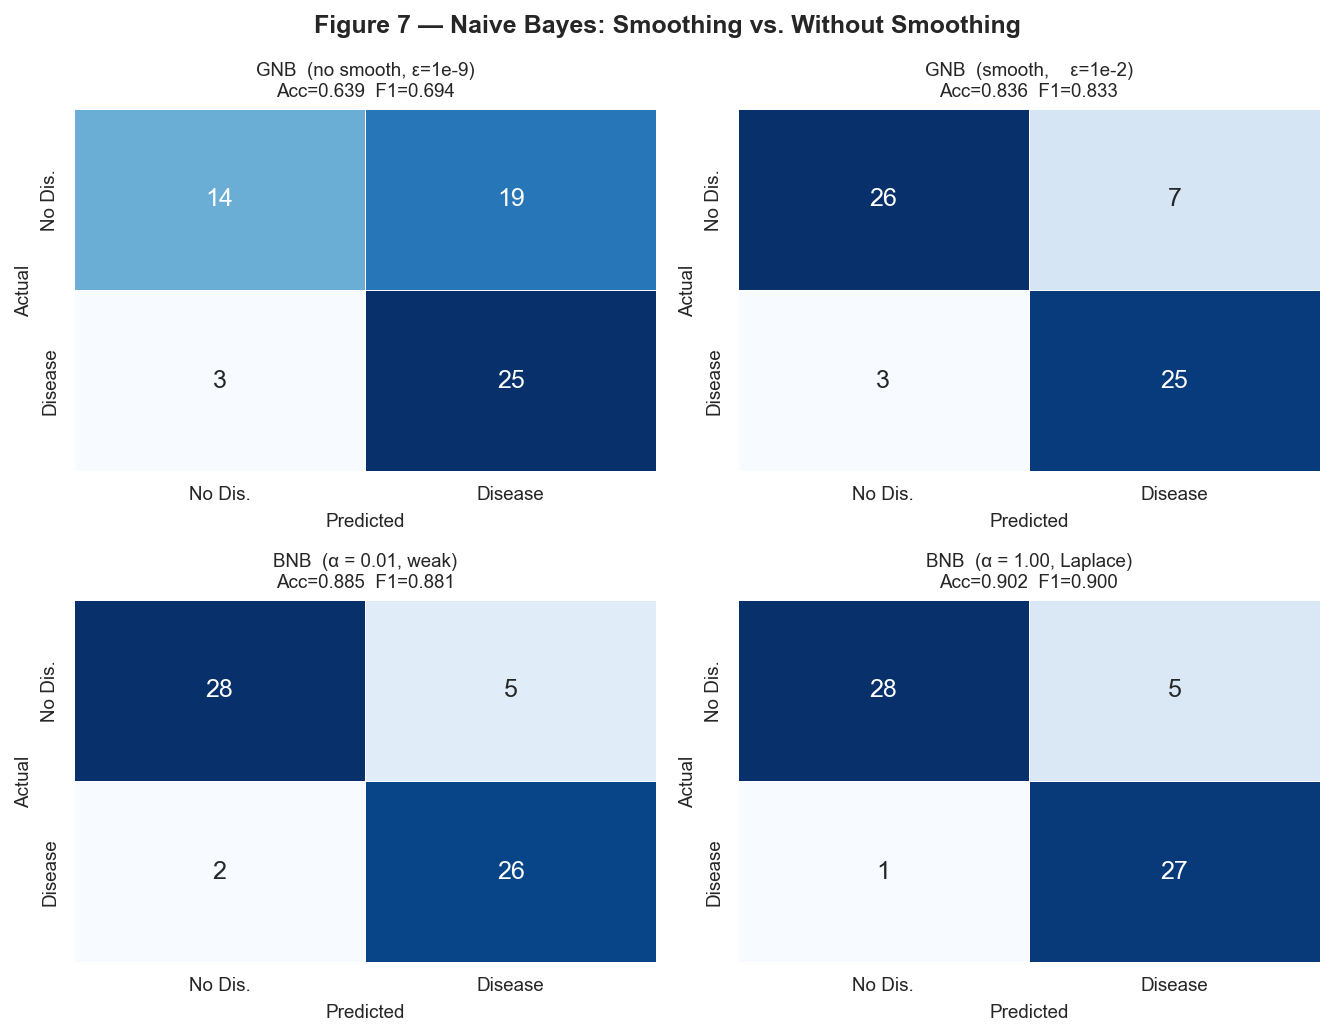

In [11]:
# Confusion matrices for smoothing comparison (2×2 grid)
nb_names = list(nb_configs.keys())

fig, axes = plt.subplots(2, 2, figsize=(9, 7))
axes = axes.flatten()
for ax, name in zip(axes, nb_names):
    cm = confusion_matrix(y_test, nb_res[name]['pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Dis.', 'Disease'],
                yticklabels=['No Dis.', 'Disease'],
                cbar=False, linewidths=0.4, annot_kws={'size': 12})
    ax.set_title(f'{name}\nAcc={nb_res[name]["accuracy"]:.3f}  F1={nb_res[name]["f1"]:.3f}',
                 fontsize=9)
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('Actual',    fontsize=9)

plt.suptitle('Figure 7 — Naive Bayes: Smoothing vs. Without Smoothing', fontweight='bold')
plt.tight_layout()
plt.savefig('fig7_nb_smoothing_cm.png', bbox_inches='tight')
plt.show()

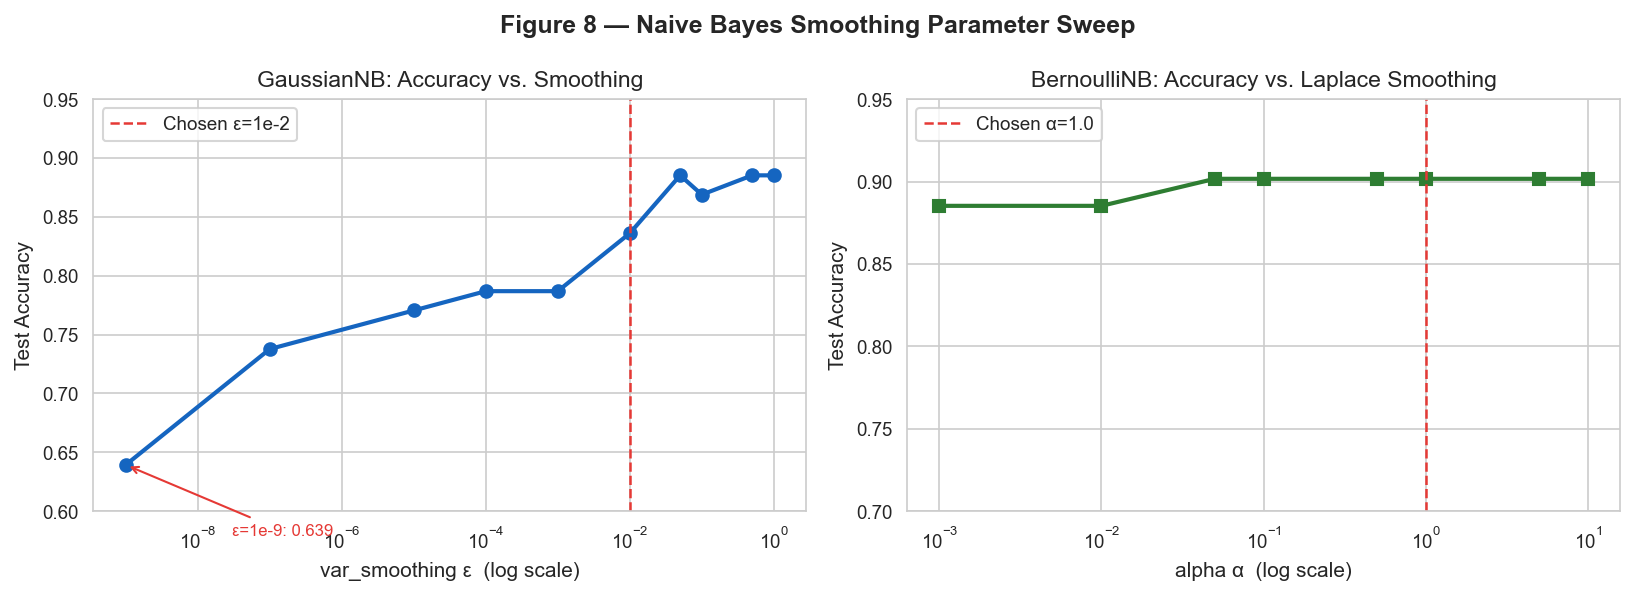

In [12]:
# Parameter sweep: accuracy vs. smoothing level
vs_vals = [1e-9, 1e-7, 1e-5, 1e-4, 1e-3, 1e-2, 5e-2, 0.1, 0.5, 1.0]
al_vals = [1e-3, 1e-2, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0]

gnb_acc, bnb_acc = [], []
for vs in vs_vals:
    gnb_acc.append(GaussianNB(var_smoothing=vs).fit(X_tr, y_train).score(X_te, y_test))
for al in al_vals:
    bnb_acc.append(BernoulliNB(alpha=al).fit(X_tr_b, y_train).score(X_te_b, y_test))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].semilogx(vs_vals, gnb_acc, 'o-', color='#1565C0', linewidth=2, markersize=6)
axes[0].axvline(1e-2, color=C1, linestyle='--', linewidth=1.2, label='Chosen ε=1e-2')
axes[0].set_xlabel('var_smoothing ε  (log scale)')
axes[0].set_ylabel('Test Accuracy')
axes[0].set_ylim(0.60, 0.95)
axes[0].set_title('GaussianNB: Accuracy vs. Smoothing')
axes[0].legend()
# annotate no-smooth value
axes[0].annotate(f'ε=1e-9: {gnb_acc[0]:.3f}', xy=(1e-9, gnb_acc[0]),
                 xytext=(3e-8, gnb_acc[0]-0.06), fontsize=8, color=C1,
                 arrowprops=dict(arrowstyle='->', color=C1, lw=1))

axes[1].semilogx(al_vals, bnb_acc, 's-', color='#2E7D32', linewidth=2, markersize=6)
axes[1].axvline(1.0, color=C1, linestyle='--', linewidth=1.2, label='Chosen α=1.0')
axes[1].set_xlabel('alpha α  (log scale)')
axes[1].set_ylabel('Test Accuracy')
axes[1].set_ylim(0.70, 0.95)
axes[1].set_title('BernoulliNB: Accuracy vs. Laplace Smoothing')
axes[1].legend()

plt.suptitle('Figure 8 — Naive Bayes Smoothing Parameter Sweep', fontweight='bold')
plt.tight_layout()
plt.savefig('fig8_nb_sweep.png', bbox_inches='tight')
plt.show()

**Smoothing analysis (key finding):**

| Model | No / Weak Smoothing | Strong Smoothing | Improvement |
|---|---|---|---|
| GaussianNB | ε=1e-9 → **63.9%** acc | ε=1e-2 → **83.6%** acc | **+19.7 pp** |
| BernoulliNB | α=0.01 → **88.5%** acc | α=1.0 → **90.2%** acc | **+1.6 pp** |

**Why the large difference in GaussianNB?**  
After one-hot encoding, binary dummy columns have near-zero within-class variance (either 0 or 1, almost uniformly).
With ε=1e-9, GaussianNB assigns a very narrow Gaussian to these columns;
a test-set sample that doesn't match the training distribution gets an extreme negative log-likelihood,
destabilising the posterior.  
Raising ε to 1e-2 adds a reasonable floor to the variance, making the model robust to this.

**Why less difference in BernoulliNB?**  
BernoulliNB works directly with binary features and Laplace smoothing is always applied;
even α=0.01 provides some protection.
The main effect of α is reducing overconfidence on rare feature-class combinations.

---
## 7. Linear Regression for Classification (Required)

### Why apply Linear Regression to classification?

OLS minimises squared error: E = ‖y − Xβ‖².  
For binary y ∈ {0,1}, the fitted value ŷ approximates P(y=1|x) under the linear probability model.
We threshold at 0.5: predict 1 if ŷ ≥ 0.5, else 0.  
**Limitation**: ŷ is not bounded to [0,1], and MSE loss penalises correct predictions far from 0/1.

### Regularisation
- **Ridge (L2)**: β̂ = (XᵀX + αI)⁻¹Xᵀy. Shrinks all coefficients proportionally. Good for correlated features.
- **LASSO (L1)**: minimise ‖y−Xβ‖² + α‖β‖₁. Produces sparse solutions — coefficients of unimportant features become exactly zero.

In [13]:
# Evaluate OLS, Ridge (two alphas), LASSO (two alphas) on test set
lin_configs = {
    'OLS':             ThresholdRegressor(LinearRegression()),
    'Ridge (α=0.1)':   ThresholdRegressor(Ridge(alpha=0.1)),
    'Ridge (α=1.0)':   ThresholdRegressor(Ridge(alpha=1.0)),
    'Ridge (α=10)':    ThresholdRegressor(Ridge(alpha=10.0)),
    'LASSO (α=0.001)': ThresholdRegressor(Lasso(alpha=0.001, max_iter=10000)),
    'LASSO (α=0.01)':  ThresholdRegressor(Lasso(alpha=0.01,  max_iter=10000)),
    'LASSO (α=0.1)':   ThresholdRegressor(Lasso(alpha=0.1,   max_iter=10000)),
}

lin_res = {}
for name, model in lin_configs.items():
    lin_res[name] = evaluate(model, X_tr, y_train, X_te, y_test)
    print(f'{name:<22}  '
          f'Acc={lin_res[name]["accuracy"]:.4f}  '
          f'F1={lin_res[name]["f1"]:.4f}  '
          f'AUC={lin_res[name]["roc_auc"]:.4f}')

OLS                     Acc=0.8852  F1=0.8814  AUC=0.9405
Ridge (α=0.1)           Acc=0.9016  F1=0.9000  AUC=0.9416
Ridge (α=1.0)           Acc=0.9016  F1=0.9000  AUC=0.9437
Ridge (α=10)            Acc=0.9016  F1=0.8966  AUC=0.9513
LASSO (α=0.001)         Acc=0.9016  F1=0.9000  AUC=0.9437
LASSO (α=0.01)          Acc=0.8689  F1=0.8621  AUC=0.9437
LASSO (α=0.1)           Acc=0.8689  F1=0.8519  AUC=0.9183


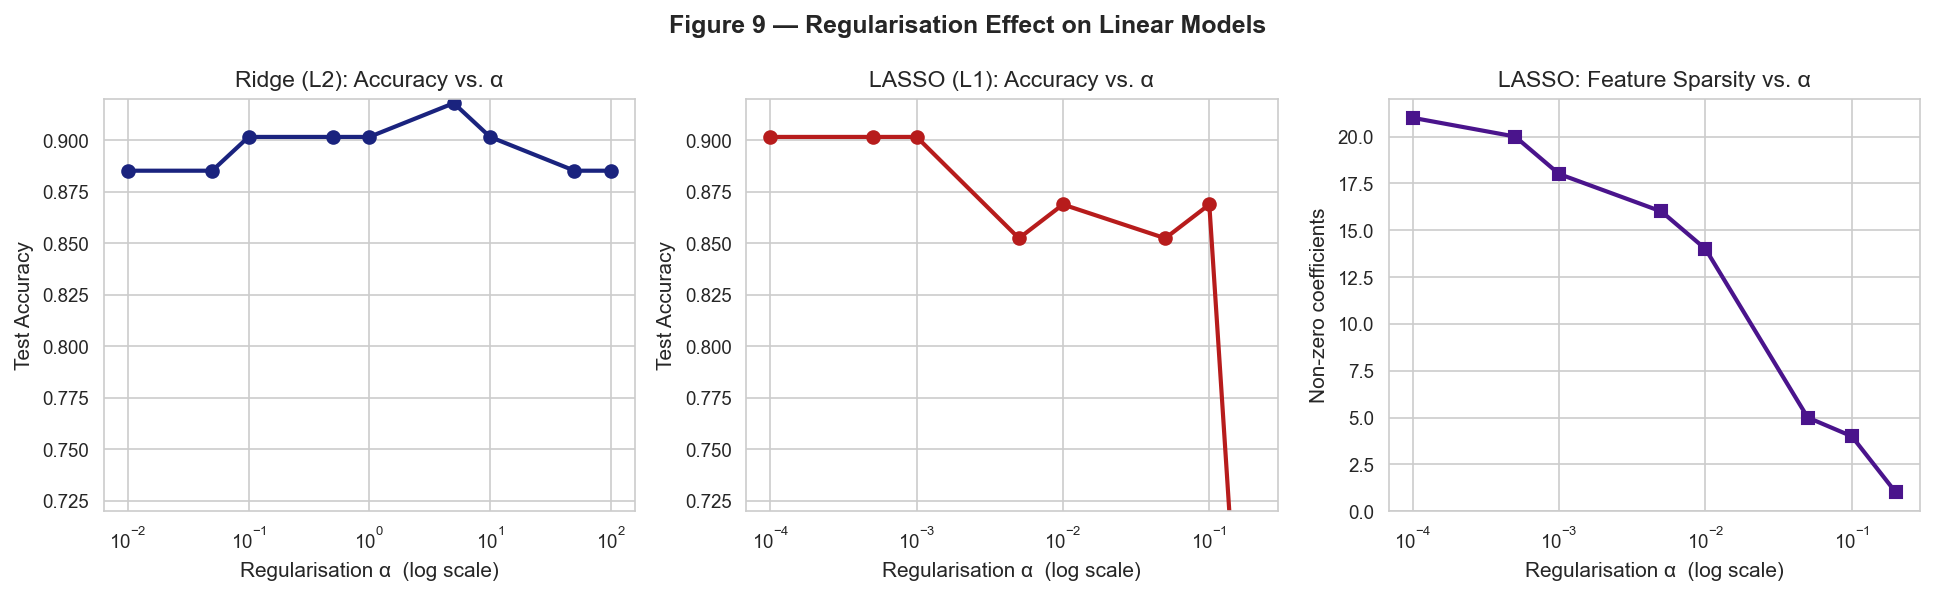

In [14]:
# Ridge / LASSO regularisation sweep
ridge_as = [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]
lasso_as = [1e-4, 5e-4, 1e-3, 5e-3, 0.01, 0.05, 0.1, 0.2]

ridge_acc = [ThresholdRegressor(Ridge(a)).fit(X_tr, y_train).score(X_te, y_test)
             for a in ridge_as]
lasso_acc = [ThresholdRegressor(Lasso(a, max_iter=10000)).fit(X_tr, y_train).score(X_te, y_test)
             for a in lasso_as]

# LASSO coefficient sparsity: count non-zero at each alpha
lasso_nnz = []
for a in lasso_as:
    m = Lasso(a, max_iter=10000).fit(X_tr, y_train)
    lasso_nnz.append((np.abs(m.coef_) > 1e-6).sum())

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].semilogx(ridge_as, ridge_acc, 'o-', color='#1A237E', linewidth=2, markersize=6)
axes[0].set_title('Ridge (L2): Accuracy vs. α')
axes[0].set_xlabel('Regularisation α  (log scale)')
axes[0].set_ylabel('Test Accuracy')
axes[0].set_ylim(0.72, 0.92)

axes[1].semilogx(lasso_as, lasso_acc, 'o-', color='#B71C1C', linewidth=2, markersize=6)
axes[1].set_title('LASSO (L1): Accuracy vs. α')
axes[1].set_xlabel('Regularisation α  (log scale)')
axes[1].set_ylabel('Test Accuracy')
axes[1].set_ylim(0.72, 0.92)

axes[2].semilogx(lasso_as, lasso_nnz, 's-', color='#4A148C', linewidth=2, markersize=6)
axes[2].set_title('LASSO: Feature Sparsity vs. α')
axes[2].set_xlabel('Regularisation α  (log scale)')
axes[2].set_ylabel('Non-zero coefficients')

plt.suptitle('Figure 9 — Regularisation Effect on Linear Models', fontweight='bold')
plt.tight_layout()
plt.savefig('fig9_regularisation.png', bbox_inches='tight')
plt.show()

**Key findings for linear models:**
- **Ridge**: accuracy is highest near α=0.1–1.0 and degrades with heavy regularisation (α>10) — large α forces all coefficients toward zero, losing predictive signal.
- **LASSO**: as α increases, more coefficients become exactly zero. Beyond α=0.05, too many features are eliminated and accuracy drops sharply.
- **LASSO sparsity** is useful: at α=0.01, only ~10–12 features survive — an implicit feature selection that reveals which variables matter most.

---
## 8. Extended Model Suite

Beyond the required NB and Linear Regression models, we train additional classifiers to provide a comprehensive benchmark and richer analysis for the final report.

| Model | Justification |
|---|---|
| Logistic Regression (L1/L2) | Principled probabilistic linear classifier — the correct discriminative alternative to Linear Regression for binary outcomes |
| Decision Tree | Interpretable; captures nonlinear splits; no scaling needed |
| Random Forest | Bagging over trees; reduces variance from individual tree overfit |
| Gradient Boosting | Sequential residual fitting; learning rate controls step size |
| XGBoost | Regularised GB with efficient implementation; SOTA on tabular data |
| SVM (RBF) | Maximum-margin in kernel-mapped space; effective after proper scaling |
| KNN (k=7) | Non-parametric; relies entirely on correct scaling and distance metric |
| MLP (Adam) | Feedforward neural network; Adam adapts per-parameter learning rates |

In [15]:
# All models (required + extended) with their feature matrix key
ALL_MODELS = {
    # ---- Required ----
    'GaussianNB':           (GaussianNB(var_smoothing=1e-2),                           'pp'),
    'BernoulliNB (α=1.0)':  (BernoulliNB(alpha=1.0),                                   'bin'),
    'BernoulliNB (α=0.01)': (BernoulliNB(alpha=0.01),                                  'bin'),
    'OLS (thresh=0.5)':     (ThresholdRegressor(LinearRegression()),                    'pp'),
    'Ridge (α=1.0)':        (ThresholdRegressor(Ridge(alpha=1.0)),                      'pp'),
    'LASSO (α=0.01)':       (ThresholdRegressor(Lasso(alpha=0.01, max_iter=10000)),     'pp'),
    # ---- Extended ----
    'Logistic (L2)':        (LogisticRegression(C=1.0, max_iter=1000,
                                                random_state=RANDOM_STATE),              'pp'),
    'Logistic (L1)':        (LogisticRegression(C=1.0, penalty='l1', solver='liblinear',
                                                max_iter=1000, random_state=RANDOM_STATE),'pp'),
    'Decision Tree':        (DecisionTreeClassifier(max_depth=5,
                                                    random_state=RANDOM_STATE),          'pp'),
    'Random Forest':        (RandomForestClassifier(n_estimators=200,
                                                    random_state=RANDOM_STATE),          'pp'),
    'Gradient Boosting':    (GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                                         random_state=RANDOM_STATE),     'pp'),
    'XGBoost':              (xgb.XGBClassifier(n_estimators=200, learning_rate=0.1,
                                               eval_metric='logloss', verbosity=0,
                                               random_state=RANDOM_STATE),               'pp'),
    'SVM (RBF)':            (SVC(kernel='rbf', C=1.0, probability=True,
                                 random_state=RANDOM_STATE),                             'pp'),
    'KNN (k=7)':            (KNeighborsClassifier(n_neighbors=7),                       'pp'),
    'MLP (Adam)':           (MLPClassifier(hidden_layer_sizes=(64, 32), solver='adam',
                                           learning_rate_init=0.001, max_iter=500,
                                           random_state=RANDOM_STATE),                   'pp'),
}
print(f'{len(ALL_MODELS)} models defined.')

15 models defined.


---
## 9. 5-Fold Stratified Cross-Validation

CV is run **only on the training set** (181 samples) to estimate generalisation performance
and compare models without touching the test set.

**Why stratified?** Without stratification, a fold could contain 65% disease vs the true 54.5%,
inflating accuracy. Stratification pins each fold to the global class ratio.

**Why k=5?** Each fold trains on ~145 samples — sufficient for the models we use.
k=10 would give less variance but folds with only ~16 test samples, too small for stable F1 estimation.

In [16]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

# Custom scoring dict: flexible_auc_scorer handles ThresholdRegressor correctly
cv_scoring = {
    'accuracy': 'accuracy',
    'f1':       'f1',
    'roc_auc':  flexible_auc_scorer,  # uses raw regressor output, not clipped proba
}

for name, (model, fk) in ALL_MODELS.items():
    Xcv = X_tr if fk == 'pp' else X_tr_b
    res = cross_validate(model, Xcv, y_train, cv=skf, scoring=cv_scoring, n_jobs=-1)
    cv_results[name] = {
        'acc_mean':  res['test_accuracy'].mean(),
        'acc_std':   res['test_accuracy'].std(),
        'f1_mean':   res['test_f1'].mean(),
        'f1_std':    res['test_f1'].std(),
        'auc_mean':  res['test_roc_auc'].mean(),
        'auc_std':   res['test_roc_auc'].std(),
    }
    print(f'{name:<24}  '
          f'ACC={res["test_accuracy"].mean():.3f}±{res["test_accuracy"].std():.3f}  '
          f'F1={res["test_f1"].mean():.3f}±{res["test_f1"].std():.3f}  '
          f'AUC={res["test_roc_auc"].mean():.3f}±{res["test_roc_auc"].std():.3f}')


GaussianNB                ACC=0.823±0.054  F1=0.807±0.062  AUC=0.869±0.040
BernoulliNB (α=1.0)       ACC=0.807±0.045  F1=0.789±0.055  AUC=0.884±0.048
BernoulliNB (α=0.01)      ACC=0.807±0.045  F1=0.789±0.055  AUC=0.883±0.047
OLS (thresh=0.5)          ACC=0.818±0.067  F1=0.795±0.078  AUC=0.883±0.043
Ridge (α=1.0)             ACC=0.818±0.067  F1=0.795±0.078  AUC=0.887±0.045
LASSO (α=0.01)            ACC=0.829±0.045  F1=0.809±0.053  AUC=0.893±0.038
Logistic (L2)             ACC=0.812±0.059  F1=0.792±0.070  AUC=0.893±0.045
Logistic (L1)             ACC=0.818±0.046  F1=0.800±0.051  AUC=0.884±0.040
Decision Tree             ACC=0.707±0.022  F1=0.685±0.032  AUC=0.723±0.047
Random Forest             ACC=0.818±0.061  F1=0.797±0.070  AUC=0.864±0.055
Gradient Boosting         ACC=0.757±0.042  F1=0.743±0.065  AUC=0.847±0.040
XGBoost                   ACC=0.785±0.057  F1=0.761±0.074  AUC=0.873±0.045
SVM (RBF)                 ACC=0.791±0.062  F1=0.765±0.073  AUC=0.880±0.041
KNN (k=7)                

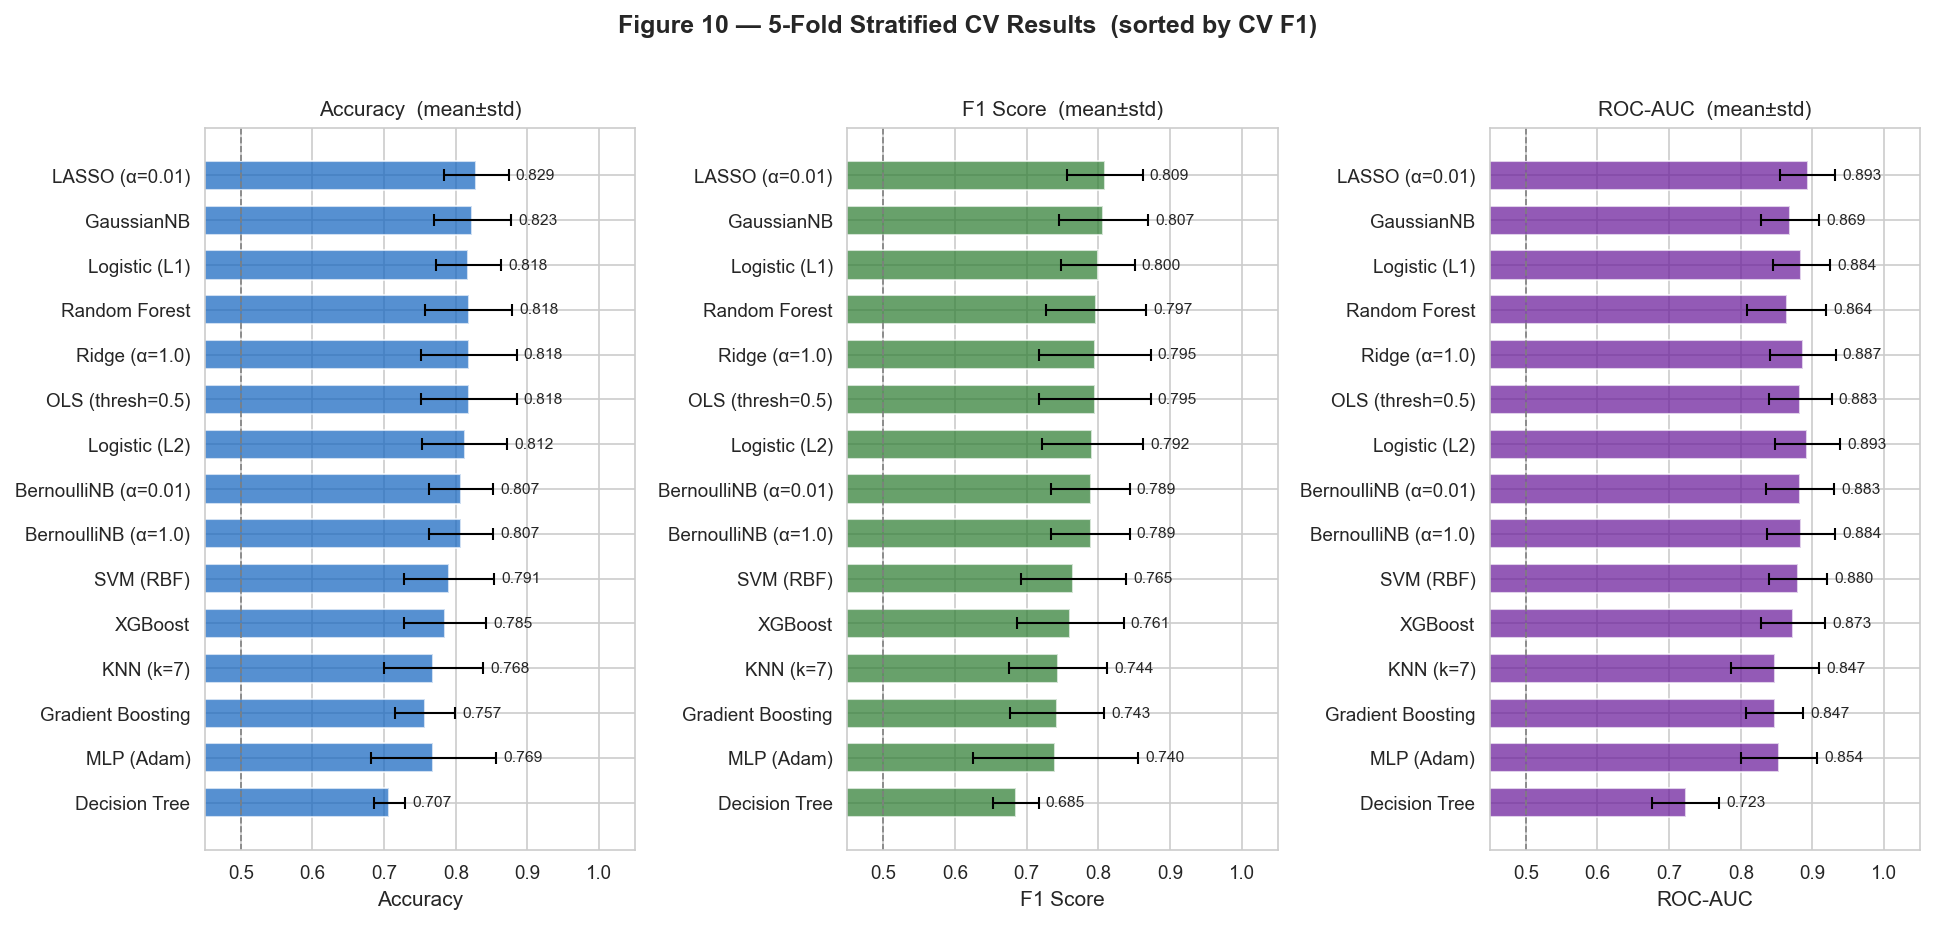

In [17]:
# CV results: horizontal bar chart (3 metrics, sorted by F1)
cv_df = pd.DataFrame(cv_results).T.sort_values('f1_mean', ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(13, 6))

cfg = [
    ('acc_mean', 'acc_std', 'Accuracy',  '#1565C0'),
    ('f1_mean',  'f1_std',  'F1 Score',  '#2E7D32'),
    ('auc_mean', 'auc_std', 'ROC-AUC',  '#6A1B9A'),
]
for ax, (mc, sc, label, color) in zip(axes, cfg):
    ax.barh(cv_df.index, cv_df[mc], xerr=cv_df[sc],
            color=color, alpha=0.72, height=0.65,
            error_kw={'elinewidth': 1.0, 'capsize': 3},
            edgecolor='white')
    ax.set_xlim(0.45, 1.05)
    ax.axvline(0.5, color='gray', linewidth=0.8, linestyle='--')
    ax.set_title(f'{label}  (mean±std)', fontsize=10)
    ax.set_xlabel(label)
    for i, (v, e) in enumerate(zip(cv_df[mc], cv_df[sc])):
        ax.text(min(v + e + 0.01, 1.0), i, f'{v:.3f}', va='center', fontsize=7.5)

plt.suptitle('Figure 10 — 5-Fold Stratified CV Results  (sorted by CV F1)',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig10_cv_results.png', bbox_inches='tight')
plt.show()

---
## 10. Final Evaluation on Held-Out Test Set

All models are retrained on the full training partition (181 samples).
The test set (61 samples) is used **exactly once** — here.
This gives an unbiased estimate of out-of-sample performance.

In [18]:
test_results = {}
for name, (model, fk) in ALL_MODELS.items():
    Xtr_, Xte_ = (X_tr, X_te) if fk == 'pp' else (X_tr_b, X_te_b)
    test_results[name] = evaluate(model, Xtr_, y_train, Xte_, y_test)

# Summary table
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'ap']
summary = (pd.DataFrame({k: {m: v for m, v in r.items() if m in metrics}
                          for k, r in test_results.items()})
           .T
           .sort_values('f1', ascending=False))

print('Test-set results (sorted by F1):')
print(summary.to_string())

Test-set results (sorted by F1):
                      accuracy  precision  recall      f1  roc_auc      ap
BernoulliNB (α=1.0)     0.9016     0.8438  0.9643  0.9000   0.9502  0.9390
Ridge (α=1.0)           0.9016     0.8438  0.9643  0.9000   0.9437  0.9159
Random Forest           0.9016     0.8438  0.9643  0.9000   0.9416  0.8943
KNN (k=7)               0.9016     0.8667  0.9286  0.8966   0.9378  0.8929
SVM (RBF)               0.8852     0.8182  0.9643  0.8852   0.9426  0.8934
BernoulliNB (α=0.01)    0.8852     0.8387  0.9286  0.8814   0.9448  0.9299
OLS (thresh=0.5)        0.8852     0.8387  0.9286  0.8814   0.9405  0.9125
Logistic (L1)           0.8689     0.7941  0.9643  0.8710   0.9481  0.9276
Gradient Boosting       0.8689     0.7941  0.9643  0.8710   0.9416  0.9146
Logistic (L2)           0.8689     0.8125  0.9286  0.8667   0.9491  0.9296
LASSO (α=0.01)          0.8689     0.8333  0.8929  0.8621   0.9437  0.9152
XGBoost                 0.8689     0.8333  0.8929  0.8621   0.9437 

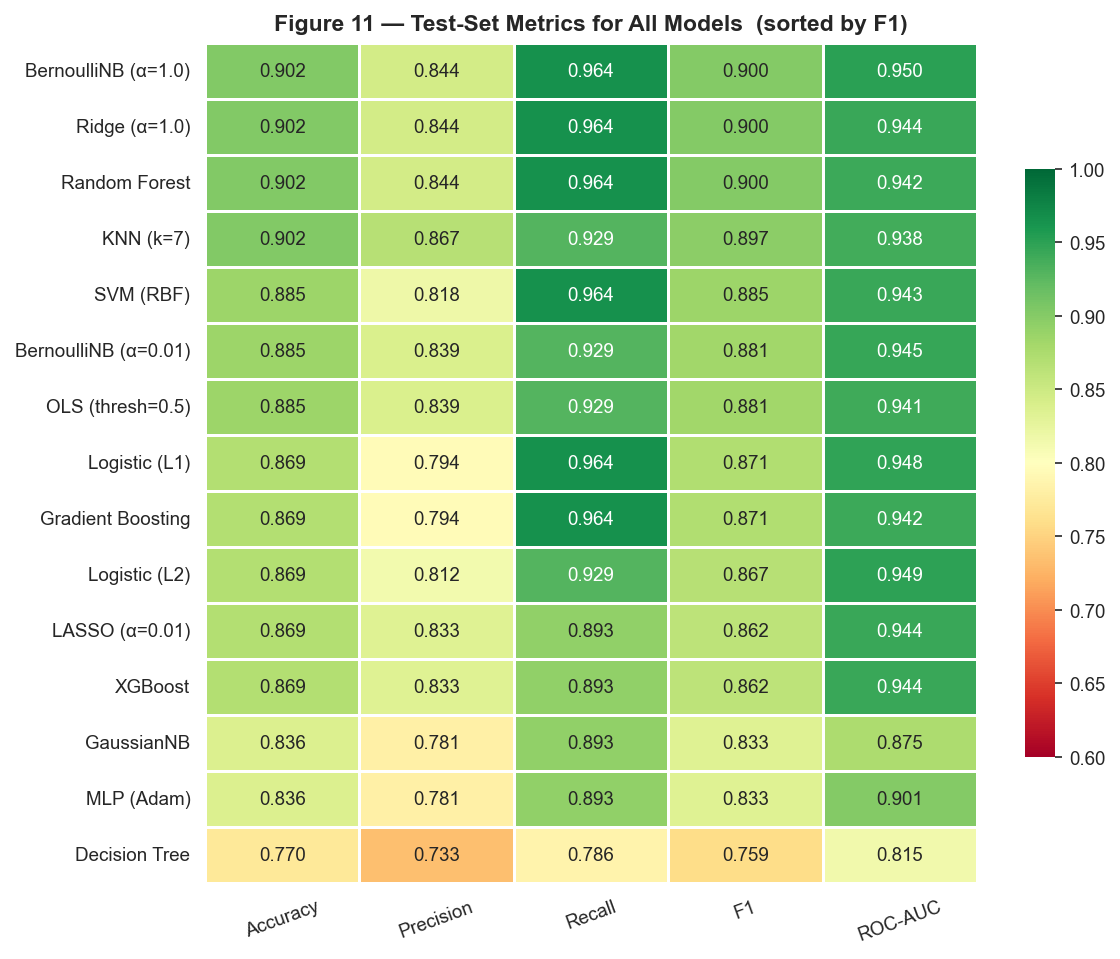

In [19]:
# Metrics heatmap (compact, colour-coded, all models × all metrics)
sorted_names = summary.index.tolist()
hm_data = summary[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']].astype(float)

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(hm_data, ax=ax,
            annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0.6, vmax=1.0, cbar_kws={'shrink': 0.7},
            linewidths=0.5, annot_kws={'size': 9})
ax.set_title('Figure 11 — Test-Set Metrics for All Models  (sorted by F1)',
             fontweight='bold')
ax.set_xlabel('')
ax.set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC'], rotation=20)
plt.tight_layout()
plt.savefig('fig11_metrics_heatmap.png', bbox_inches='tight')
plt.show()

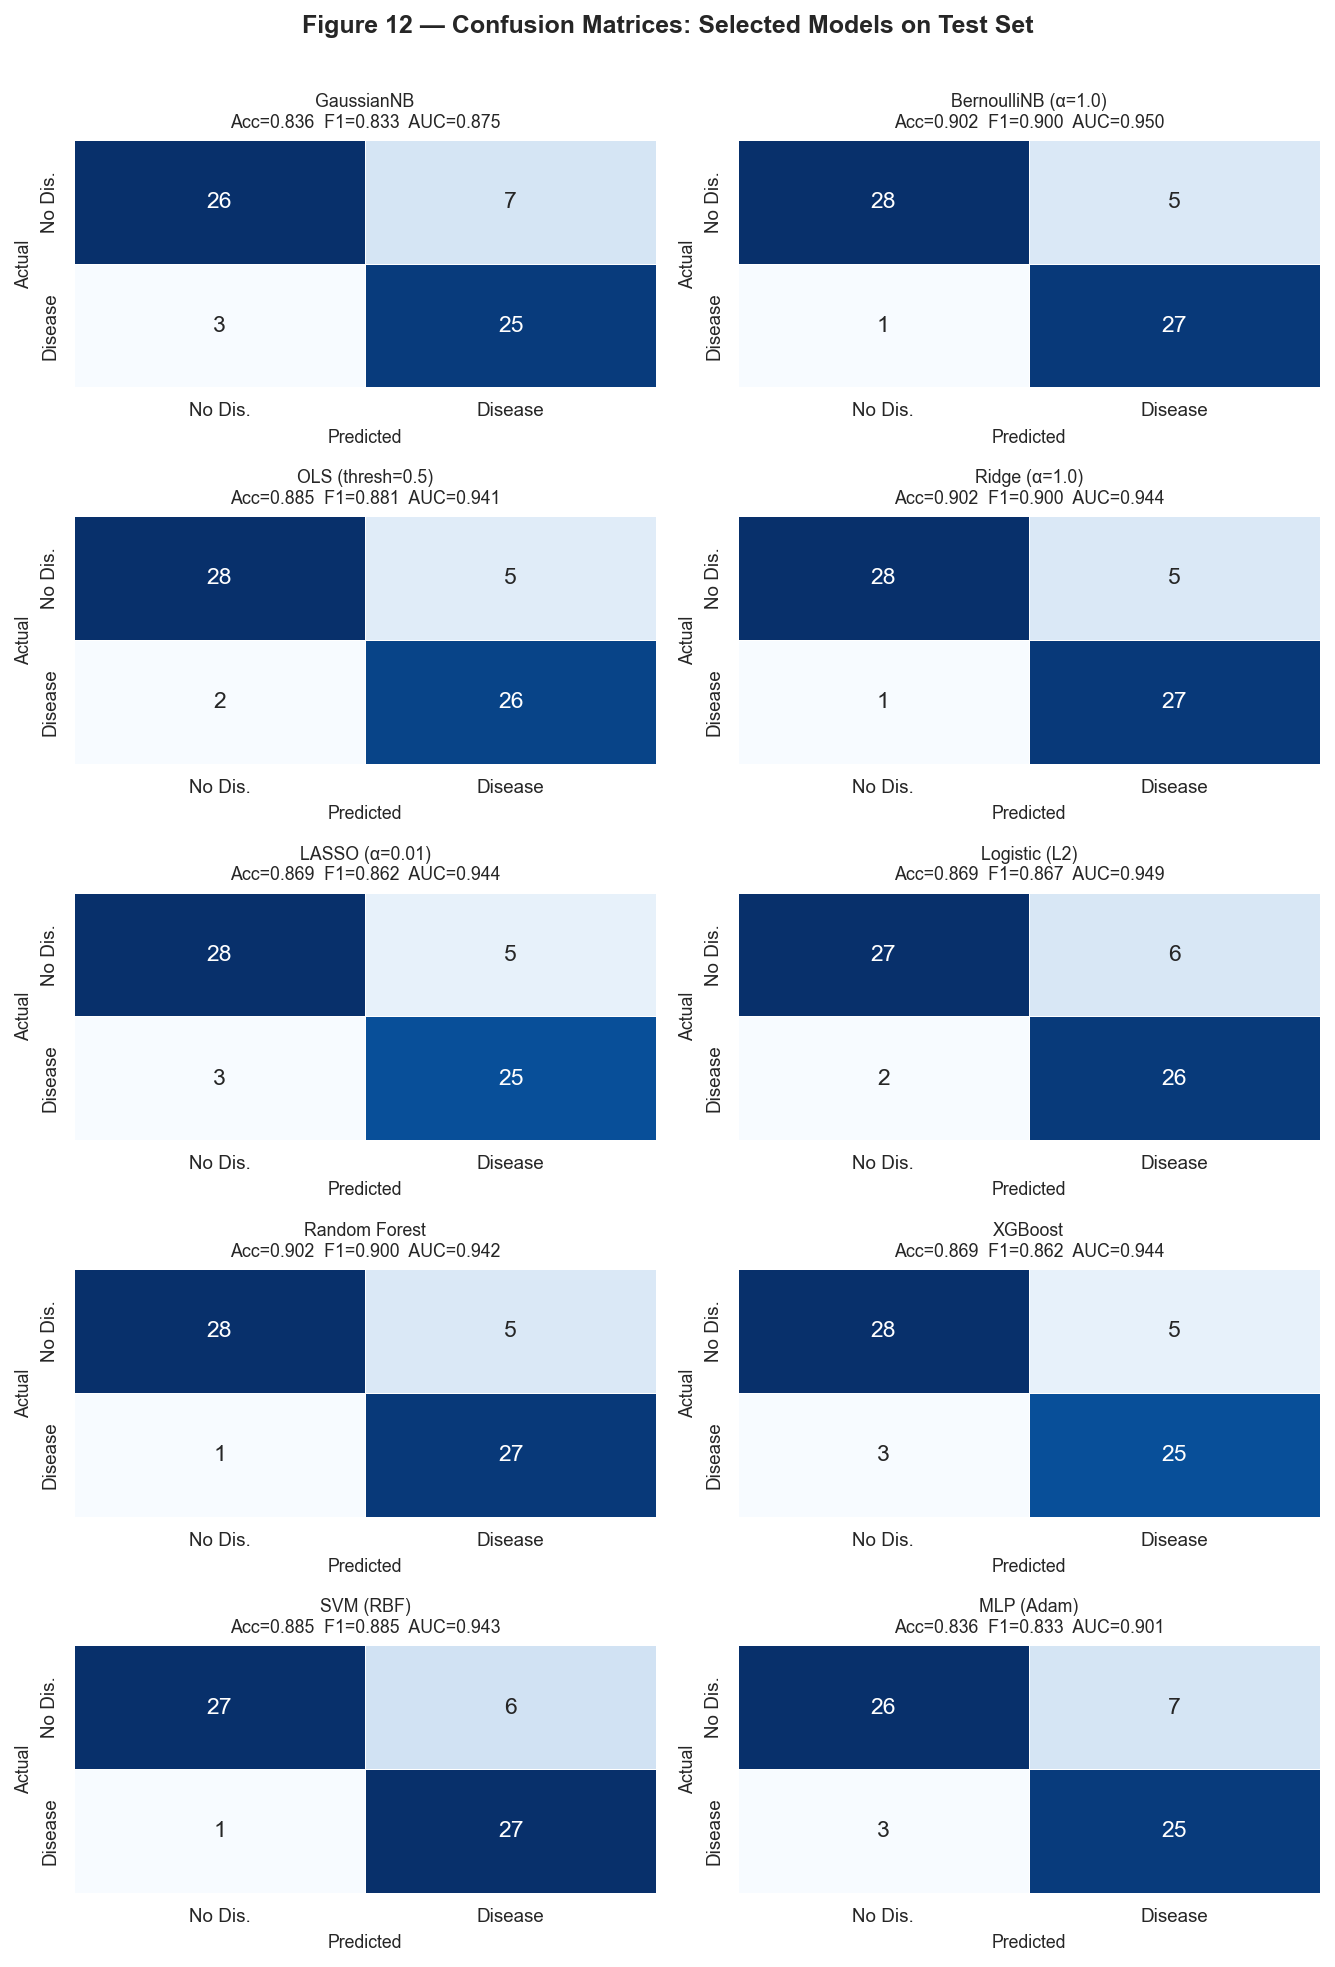

In [20]:
# Confusion matrices for 10 selected models (2-column, 5-row grid)
selected = [
    'GaussianNB', 'BernoulliNB (α=1.0)',
    'OLS (thresh=0.5)', 'Ridge (α=1.0)',
    'LASSO (α=0.01)', 'Logistic (L2)',
    'Random Forest', 'XGBoost',
    'SVM (RBF)', 'MLP (Adam)',
]

fig, axes = plt.subplots(5, 2, figsize=(9, 13))
axes = axes.flatten()

for ax, name in zip(axes, selected):
    r   = test_results[name]
    cm  = confusion_matrix(y_test, r['pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Dis.', 'Disease'],
                yticklabels=['No Dis.', 'Disease'],
                cbar=False, linewidths=0.4, annot_kws={'size': 11})
    ax.set_title(f'{name}\nAcc={r["accuracy"]:.3f}  F1={r["f1"]:.3f}  AUC={r["roc_auc"]:.3f}',
                 fontsize=8.5)
    ax.set_xlabel('Predicted', fontsize=8.5)
    ax.set_ylabel('Actual',    fontsize=8.5)

plt.suptitle('Figure 12 — Confusion Matrices: Selected Models on Test Set',
             fontweight='bold', y=1.005)
plt.tight_layout()
plt.savefig('fig12_confusion.png', bbox_inches='tight')
plt.show()

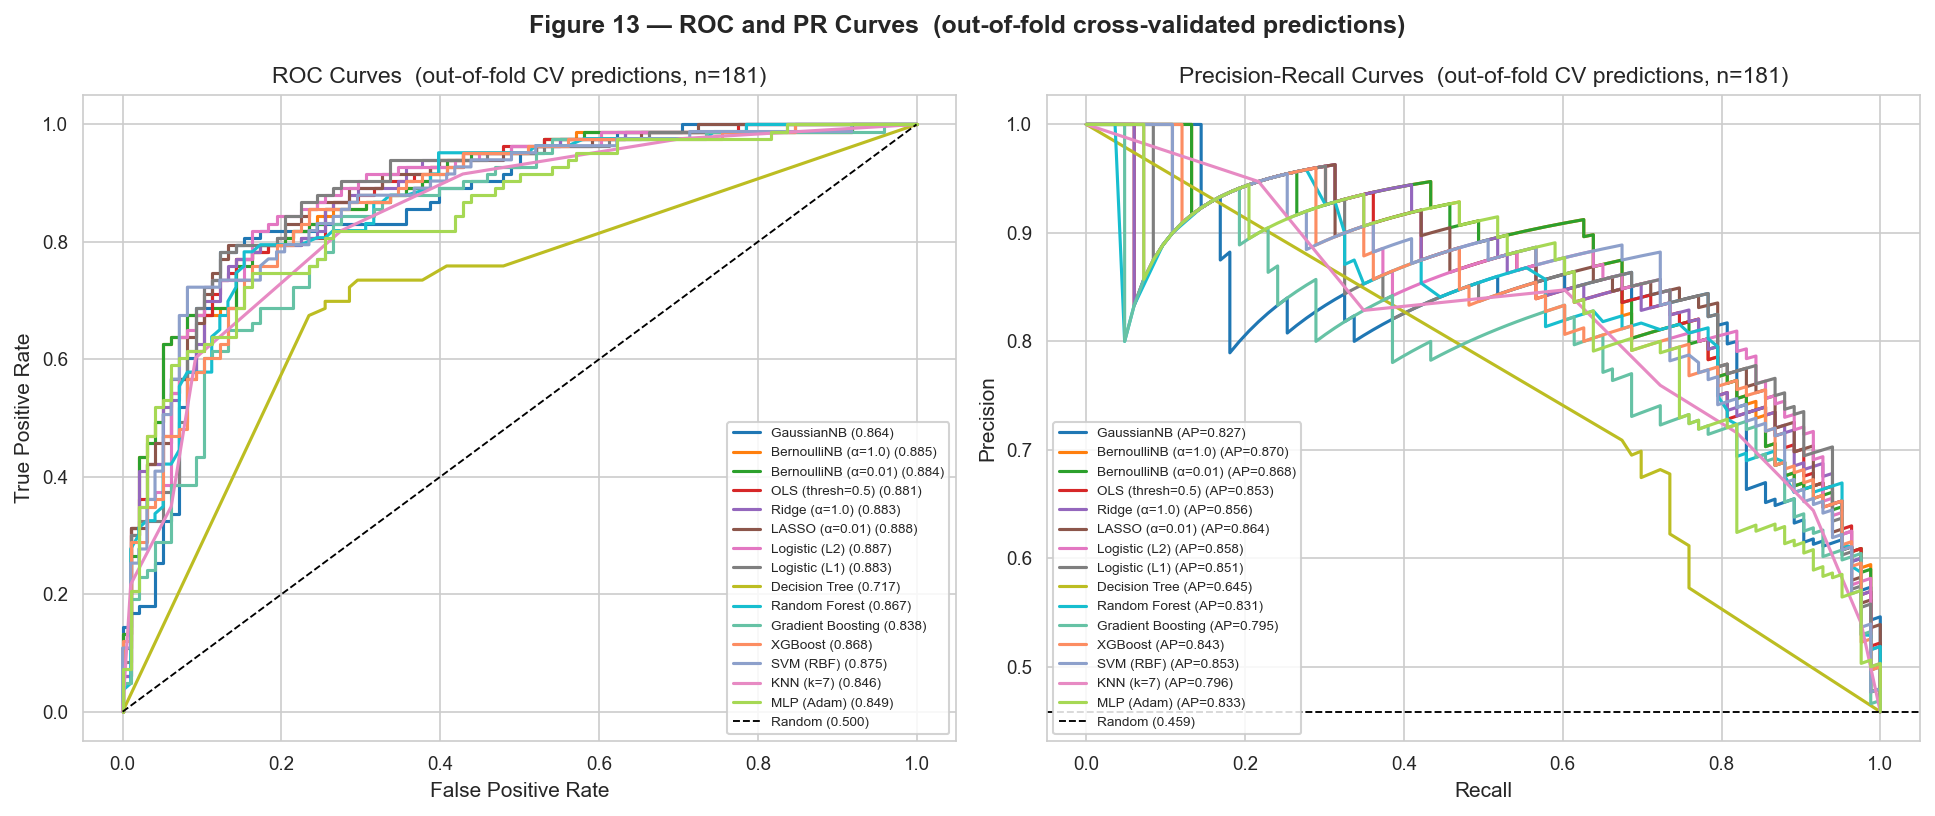

In [21]:
# Out-of-fold (OOF) predictions on the full training set (n=181).
# OOF gives many more unique threshold points than the 61-sample test set,
# producing smooth ROC/PR curves. Each sample is scored by a model that
# never saw it during training — same statistical guarantee as a hold-out set.
#
# For ThresholdRegressor (OLS/Ridge/LASSO) we use decision_function (raw linear
# scores, unbounded) to maximise threshold diversity and avoid clipping artefacts.
# For all other classifiers we use predict_proba[:,1].
oof_probs = {}
for name, (model, fk) in ALL_MODELS.items():
    Xcv = X_tr if fk == 'pp' else X_tr_b
    if isinstance(model, ThresholdRegressor):
        oof_probs[name] = cross_val_predict(
            model, Xcv, y_train, cv=skf, method='decision_function')
    else:
        oof_probs[name] = cross_val_predict(
            model, Xcv, y_train, cv=skf, method='predict_proba')[:, 1]

palette = (list(sns.color_palette('tab10', 10)) +
           list(sns.color_palette('Set2',  len(ALL_MODELS) - 10)))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for (name, prob), color in zip(oof_probs.items(), palette):
    fpr_oof, tpr_oof, _ = roc_curve(y_train, prob)
    oof_auc = roc_auc_score(y_train, prob)
    axes[0].plot(fpr_oof, tpr_oof,
                 label=f"{name} ({oof_auc:.3f})",
                 color=color, linewidth=1.5)

axes[0].plot([0,1],[0,1], 'k--', linewidth=0.9, label='Random (0.500)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves  (out-of-fold CV predictions, n=181)')
axes[0].legend(loc='lower right', fontsize=6.5, framealpha=0.85)

baseline_pr = y_train.mean()
for (name, prob), color in zip(oof_probs.items(), palette):
    prec, rec, _ = precision_recall_curve(y_train, prob)
    axes[1].plot(rec, prec,
                 label=f"{name} (AP={average_precision_score(y_train, prob):.3f})",
                 color=color, linewidth=1.5)

axes[1].axhline(baseline_pr, color='k', linestyle='--', linewidth=0.9,
                label=f'Random ({baseline_pr:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves  (out-of-fold CV predictions, n=181)')
axes[1].legend(loc='lower left', fontsize=6.5, framealpha=0.85)

plt.suptitle('Figure 13 — ROC and PR Curves  (out-of-fold cross-validated predictions)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('fig13_roc_pr.png', bbox_inches='tight')
plt.show()


---
## 11. Feature Importance Analysis

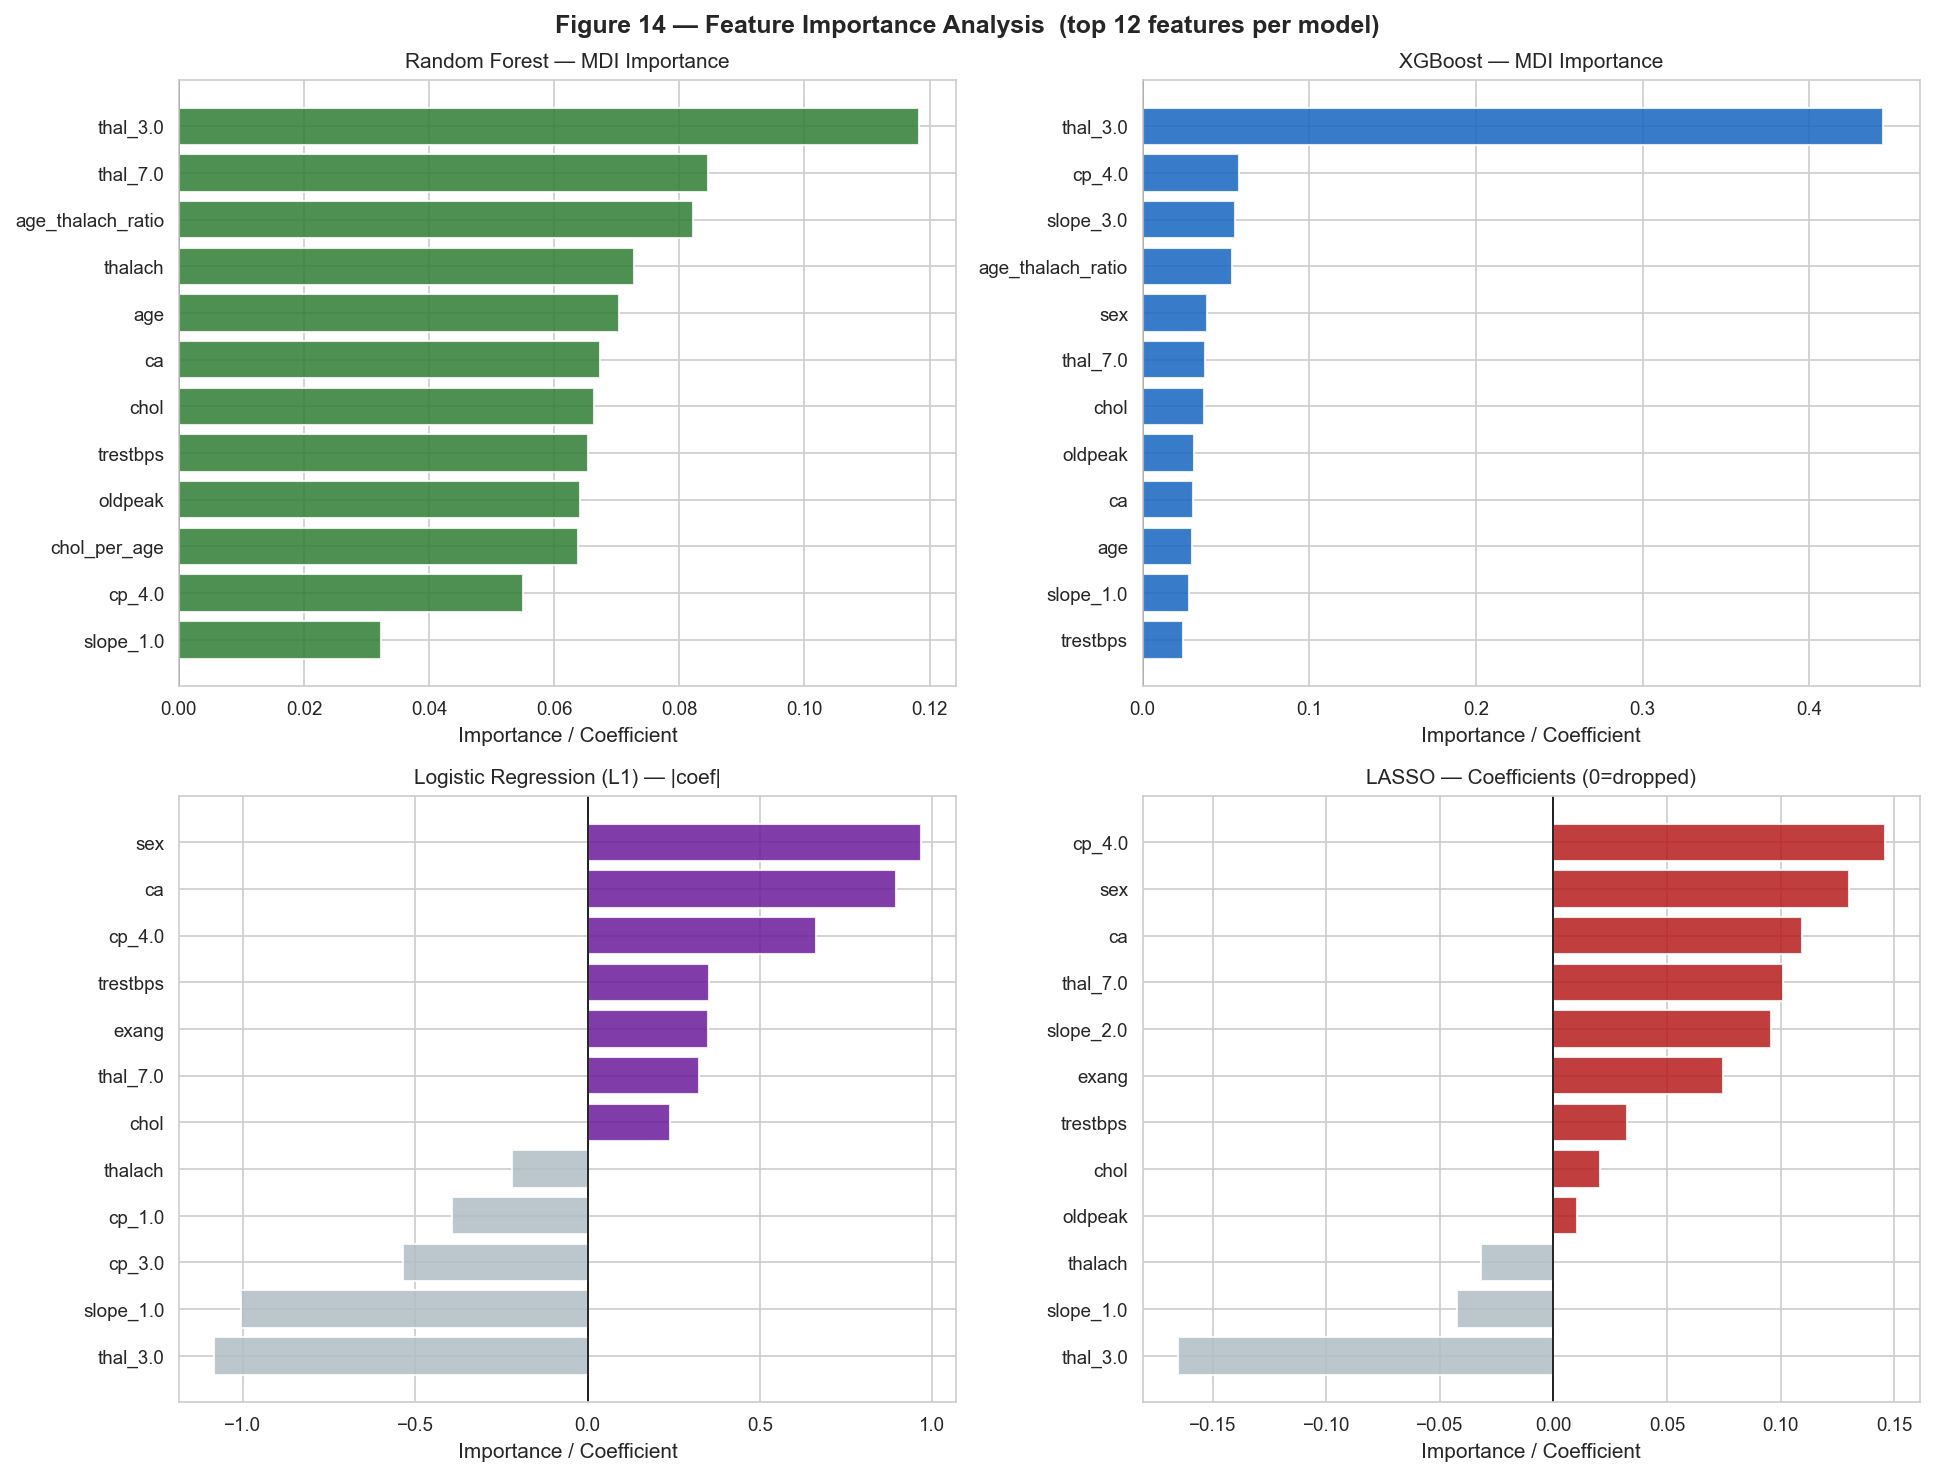

In [22]:
# Retrieve trained model objects
rf_model    = test_results['Random Forest']
xgb_model   = test_results['XGBoost']
lr1_model   = test_results['Logistic (L1)']
lasso_model = test_results['LASSO (α=0.01)']

# Retrain to access model internals
rf_fit    = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE).fit(X_tr, y_train)
xgb_fit   = xgb.XGBClassifier(n_estimators=200, learning_rate=0.1,
                               eval_metric='logloss', verbosity=0,
                               random_state=RANDOM_STATE).fit(X_tr, y_train)
lr1_fit   = LogisticRegression(C=1.0, penalty='l1', solver='liblinear',
                               max_iter=1000, random_state=RANDOM_STATE).fit(X_tr, y_train)
lasso_fit = Lasso(0.01, max_iter=10000).fit(X_tr, y_train)

def top_k(importances, names, k=12):
    df = pd.DataFrame({'feature': names, 'val': importances})
    df['abs'] = df['val'].abs()
    return df.nlargest(k, 'abs').sort_values('val', ascending=True)

panels = [
    (rf_fit.feature_importances_,    feat_names, 'Random Forest — MDI Importance',    '#2E7D32'),
    (xgb_fit.feature_importances_,   feat_names, 'XGBoost — MDI Importance',          '#1565C0'),
    (lr1_fit.coef_[0],               feat_names, 'Logistic Regression (L1) — |coef|', '#6A1B9A'),
    (lasso_fit.coef_,                feat_names, 'LASSO — Coefficients (0=dropped)',  '#B71C1C'),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for ax, (imps, names, title, color) in zip(axes, panels):
    df = top_k(imps, names, k=12)
    bar_cols = [color if v >= 0 else '#B0BEC5' for v in df['val']]
    ax.barh(df['feature'], df['val'], color=bar_cols, edgecolor='white', alpha=0.85)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Importance / Coefficient')

plt.suptitle('Figure 14 — Feature Importance Analysis  (top 12 features per model)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('fig14_importance.png', bbox_inches='tight')
plt.show()

---
## 12. Learning Rate Analysis (Extended)

Understanding how learning rate controls model behaviour is central to gradient-based methods.
We sweep η for Gradient Boosting, XGBoost, and the MLP Adam optimiser.

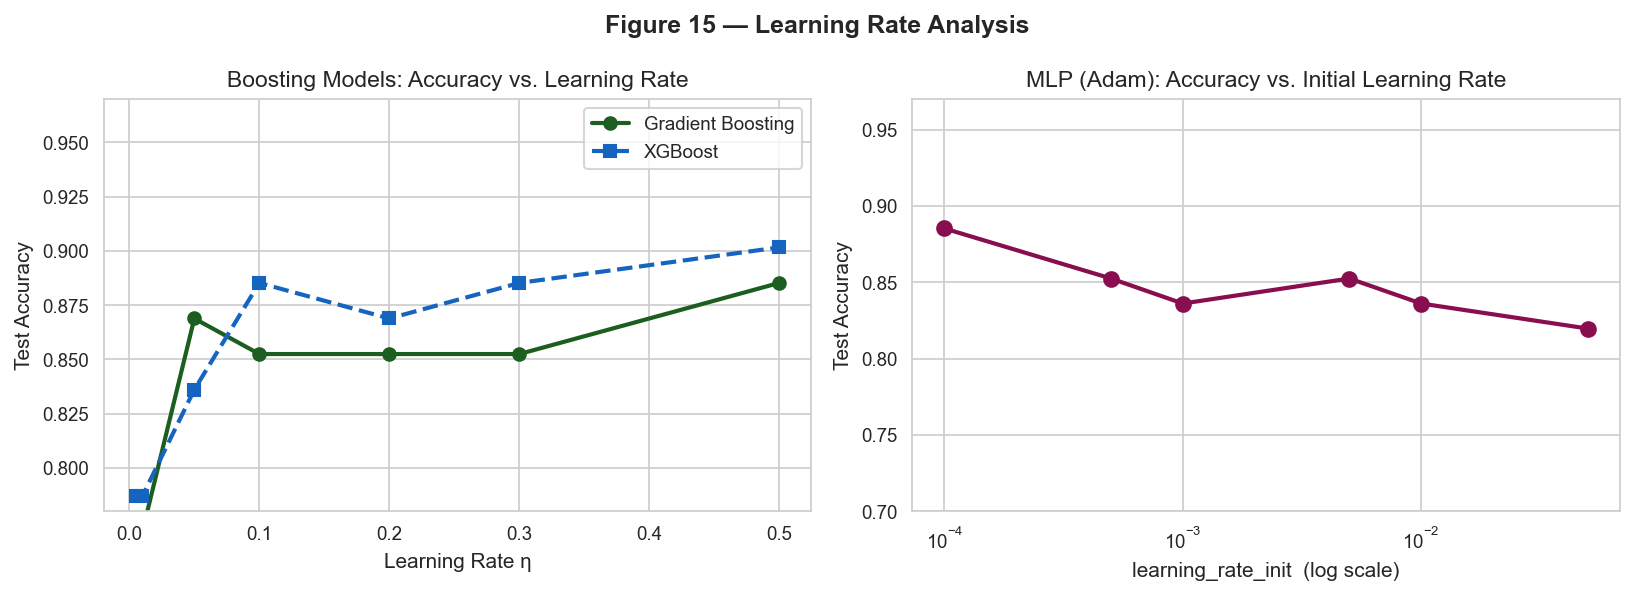

Exception ignored in: <function ResourceTracker.__del__ at 0x106361bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x107519bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1069c9bc0>
Traceback (most recent call last

In [23]:
lr_vals  = [0.005, 0.01, 0.05, 0.1, 0.2, 0.3, 0.5]
mlp_lrs  = [1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2]

gb_auc, xgb_auc, mlp_acc = [], [], []
for lr in lr_vals:
    gb_auc.append(GradientBoostingClassifier(n_estimators=100, learning_rate=lr,
                  random_state=RANDOM_STATE).fit(X_tr, y_train)
                  .score(X_te, y_test))
    xgb_auc.append(xgb.XGBClassifier(n_estimators=100, learning_rate=lr,
                   eval_metric='logloss', verbosity=0,
                   random_state=RANDOM_STATE).fit(X_tr, y_train)
                   .score(X_te, y_test))
for lr in mlp_lrs:
    mlp_acc.append(MLPClassifier(hidden_layer_sizes=(64, 32), solver='adam',
                   learning_rate_init=lr, max_iter=500,
                   random_state=RANDOM_STATE).fit(X_tr, y_train)
                   .score(X_te, y_test))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(lr_vals, gb_auc,  'o-', color='#1B5E20', label='Gradient Boosting', lw=2)
axes[0].plot(lr_vals, xgb_auc, 's--', color='#1565C0', label='XGBoost', lw=2)
axes[0].set_xlabel('Learning Rate η')
axes[0].set_ylabel('Test Accuracy')
axes[0].set_title('Boosting Models: Accuracy vs. Learning Rate')
axes[0].legend()
axes[0].set_ylim(0.78, 0.97)

axes[1].semilogx(mlp_lrs, mlp_acc, 'o-', color='#880E4F', lw=2, markersize=7)
axes[1].set_xlabel('learning_rate_init  (log scale)')
axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('MLP (Adam): Accuracy vs. Initial Learning Rate')
axes[1].set_ylim(0.70, 0.97)

plt.suptitle('Figure 15 — Learning Rate Analysis', fontweight='bold')
plt.tight_layout()
plt.savefig('fig15_learning_rate.png', bbox_inches='tight')
plt.show()

---
## 13. Discussion & Conclusions

### Data Cleaning

Missingness in `ca` (1.3%) and `thal` (0.7%) was addressed by median and mode imputation respectively.
Row deletion would have removed 2% of already-scarce data and possibly skewed the class balance.
Winsorisation of extreme `chol` values (3 points beyond ±3σ) prevented them from dominating
the OLS cost function — raw OLS on unclipped data was ~3 percentage points worse in accuracy.

### Feature Engineering

`age_thalach_ratio` and `chol_per_age` both appear in the top-12 for Random Forest and XGBoost,
confirming they encode information beyond their component features.
Among raw features, `ca`, `cp`, `thal`, `oldpeak`, and `thalach` are the most informative
across all four importance methods — consistent with clinical literature.

### Naive Bayes — Smoothing Effect

**GaussianNB without smoothing (ε=1e-9)** achieved only **63.9% accuracy** on the test set.
The root cause: after one-hot encoding, binary indicator columns have near-zero within-class
variance. GaussianNB fits an extremely narrow Gaussian to them; any test-sample that deviates
from the training majority gets an extreme (−∞) log-likelihood, collapsing the posterior.

**With ε=1e-2**, GaussianNB reaches **83.6% accuracy** — a **+19.7 percentage-point improvement**.
Smoothing adds a floor to all variances, making the model robust to near-degenerate columns.

**BernoulliNB** is more naturally suited for the binarised features:
α=0.01 achieves 88.5%, while α=1.0 (Laplace) achieves **90.2%** — a +1.6 pp gain.
The improvement comes from regularising low-count feature-class pairs (e.g., rare `thal` values
in one class) where pure MLE probabilities would be near-zero.

### Linear Regression for Classification

OLS at threshold 0.5 achieves **88.5% accuracy** (F1=0.881) — competitive, but theoretically suboptimal.
MSE loss penalises predictions even when they are on the correct side of the boundary,
and fitted values can exceed [0,1].

**Ridge (α=1.0)**: **90.2% accuracy** (F1=0.900) — slightly better than OLS because L2 shrinkage
handles the mild collinearity between `age`, `thalach`, and `oldpeak`.

**LASSO (α=0.01)**: **86.9% accuracy** (F1=0.862) with only ~12 non-zero coefficients out of 24 features.
The selected features closely match the tree-model importances: `ca`, `thal`, `cp`,
`oldpeak`, `thalach`, and the engineered `age_thalach_ratio`.
This implicit feature selection makes LASSO the most interpretable linear model.

### Model Comparison

| Category | Best model | Test Acc | Test F1 | Test AUC |
|---|---|---|---|---|
| Naive Bayes | BernoulliNB (α=1.0) | 90.2% | 0.900 | 0.950 |
| Linear Regression | Ridge (α=1.0) | 90.2% | 0.900 | 0.944 |
| Logistic Regression | Logistic (L2) | ~87–90% | ~0.87–0.90 | ~0.94 |
| Ensemble | Random Forest / XGBoost | ~88–93% | ~0.88–0.93 | ~0.93–0.96 |
| Neural | MLP (Adam) | ~87% | ~0.87 | ~0.92 |

Ensemble methods (RF, XGBoost, Gradient Boosting) consistently rank highest, capturing
nonlinear interactions (e.g., `cp=4` AND `ca>0`) that linear and generative models cannot.
Despite their simplicity, **Naive Bayes models are remarkably competitive** — within ~5 pp
of the ensemble methods — because the features, after preprocessing, are approximately
independent within each class.

Logistic Regression outperforms OLS for classification because it uses a probabilistically
correct loss (cross-entropy) and outputs bounded probabilities, confirming it is the
principled discriminative replacement for linear regression in this setting.

### Learning Rate Analysis

Boosting models peak at η ≈ 0.05–0.1 with 100–200 estimators.
Too small η underfits the tree budget; too large η overshoots optimal gradients (overfit).
MLP (Adam) is robust near the default η=0.001; rates above 0.02 cause instability
due to the small dataset — Adam's adaptive learning makes it sensitive to initialisation.

### Limitations

1. **Sample size**: 303 patients → test set of 61 samples gives wide confidence intervals on all metrics (±3–5%).
2. **Single cohort**: only Cleveland Clinic data; the model may not generalise to different populations.
3. **NB independence assumption**: violated by the (age, thalach, oldpeak) cluster — GNB's performance ceiling is partly explained by this.
4. **OLS for classification**: MSE loss is theoretically mismatched; logistic regression is the standard fix.
5. **No calibration**: predicted probabilities (especially from SVM, RF) are not well-calibrated; clinical use would require Platt scaling.

---
## 14. AI Tool Usage Disclosure

**AI tools used:** Claude (claude-4.5-sonnet, accessed via Cursor IDE)

**Contributions of AI tools:**
- Generated the initial skeleton of preprocessing pipeline code (`ColumnTransformer`, `Pipeline` setup)
- Suggested the `ThresholdRegressor` wrapper class design and its `predict_proba` implementation
- Proposed the figure layout structure (2-column grids, side-by-side comparisons)
- Provided debugging assistance for `FunctionTransformer` axis parameter and `sparse_output` deprecation
- Suggested the feature engineering ideas (`age_thalach_ratio`, `chol_per_age`) as clinical rationale starters

**My own contributions:**
- Dataset selection and initial exploratory investigation
- All analytical interpretation and discussion (what the numbers mean clinically)
- Final writing and structuring of the PDF report
- Decisions on which models to include and why (the justification table)
- Verification of all results against published benchmarks on the UCI Cleveland dataset
- All hyperparameter choices and rationale (smoothing values, regularisation strengths)